# Compare Original vs Optimized to_dataframes.py Outputs

This notebook compares the outputs from the original and optimized versions of `to_dataframes.py` to verify they produce identical results.

We'll compare:
- `truth_reco_match_n10.csv` (original)
- `truth_reco_match_n10_opt.csv` (optimized with `--tag opt`)


In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")


Libraries imported successfully!


## 1. Load the CSV Files

Load both the original and optimized outputs.


In [2]:
# Define file paths
output_dir = "/global/homes/j/jvmead/dune/light_file_processing/outputs/mr6-5_max_distance/test/"
original_file = f"{output_dir}truth_reco_match_n10.csv"
#output_dir = '/pscratch/sd/j/jvmead/to_dataframes/'
optimized_file = f"{output_dir}truth_reco_match_n10_opt.csv"

# Load the datasets
print("Loading original file...")
df_original = pd.read_csv(original_file)
print(f"Original: {len(df_original)} rows, {len(df_original.columns)} columns")

print("\nLoading optimized file...")
df_optimized = pd.read_csv(optimized_file)
print(f"Optimized: {len(df_optimized)} rows, {len(df_optimized.columns)} columns")

print("\n✓ Files loaded successfully!")


Loading original file...
Original: 22484 rows, 80 columns

Loading optimized file...
Optimized: 22484 rows, 80 columns

✓ Files loaded successfully!


In [3]:
# Check which columns differ between the two dataframes
print("=" * 80)
print("COLUMN DIFFERENCES")
print("=" * 80)

orig_cols = set(df_original.columns)
opt_cols = set(df_optimized.columns)

only_in_orig = orig_cols - opt_cols
only_in_opt = opt_cols - orig_cols

if only_in_orig:
    print(f"\nColumns ONLY in ORIGINAL ({len(only_in_orig)}):")
    for col in sorted(only_in_orig):
        print(f"  - {col}")

if only_in_opt:
    print(f"\nColumns ONLY in OPTIMIZED ({len(only_in_opt)}):")
    for col in sorted(only_in_opt):
        print(f"  - {col}")

if not only_in_orig and not only_in_opt:
    print("\n✓ Both dataframes have exactly the same columns!")

# Show all columns for comparison
print(f"\n{'='*80}")
print("ALL COLUMNS")
print(f"{'='*80}")
print(f"Original columns ({len(df_original.columns)}): {list(df_original.columns)}")
print(f"\nOptimized columns ({len(df_optimized.columns)}): {list(df_optimized.columns)}")

COLUMN DIFFERENCES

✓ Both dataframes have exactly the same columns!

ALL COLUMNS
Original columns (80): ['file_id', 'event_id', 'vertex_id', 'tpc_num', 'start_time', 'start_time_idx', 'vertex_x', 'vertex_y', 'vertex_z', 'enu', 'isCC', 'inelasticity', 'Q2', 'lep_pdg', 'nu_pdg', 'nphoton_tot', 'dE_tot', 'n_segments', 'x_mean_int', 'y_mean_int', 'z_mean_int', 'x_wmean_int', 'y_wmean_int', 'z_wmean_int', 'int_max_distance', 'int_tpc_num', 'n_int_per_tpc', 'delta_t0', 'delta_x', 'delta_y', 'delta_z', 'delta_R', 'det_0', 'det_0_dtime', 'det_0_max', 'det_1', 'det_1_dtime', 'det_1_max', 'det_2', 'det_2_dtime', 'det_2_max', 'det_3', 'det_3_dtime', 'det_3_max', 'det_4', 'det_4_dtime', 'det_4_max', 'det_5', 'det_5_dtime', 'det_5_max', 'det_6', 'det_6_dtime', 'det_6_max', 'det_7', 'det_7_dtime', 'det_7_max', 'det_8', 'det_8_dtime', 'det_8_max', 'det_9', 'det_9_dtime', 'det_9_max', 'det_10', 'det_10_dtime', 'det_10_max', 'det_11', 'det_11_dtime', 'det_11_max', 'det_12', 'det_12_dtime', 'det_12_max

In [4]:
# Quick diagnostic: Check if outputs have the bug signature
# The bug caused wrong nphoton_tot values - they should be consistent with n_photons
# In buggy version, nphoton_tot could be much larger than expected

print("=" * 80)
print("BUG SIGNATURE CHECK")
print("=" * 80)

# Check for matched rows only (have both truth and reco)
matched_orig = df_original[(df_original['vertex_id'].notna()) & (df_original[[f'det_{i}' for i in range(16)]].sum(axis=1) > 0)]
matched_opt = df_optimized[(df_optimized['vertex_id'].notna()) & (df_optimized[[f'det_{i}' for i in range(16)]].sum(axis=1) > 0)]

print(f"\nOriginal matched rows: {len(matched_orig)}")
print(f"Optimized matched rows: {len(matched_opt)}")

# Compare nphoton_tot statistics for matched rows
print(f"\nnphoton_tot statistics (matched rows):")
print(f"  Original:  mean={matched_orig['nphoton_tot'].mean():.1f}, max={matched_orig['nphoton_tot'].max():.1f}")
print(f"  Optimized: mean={matched_opt['nphoton_tot'].mean():.1f}, max={matched_opt['nphoton_tot'].max():.1f}")

# If these differ significantly, outputs are from DIFFERENT code versions
nphoton_diff = abs(matched_orig['nphoton_tot'].mean() - matched_opt['nphoton_tot'].mean())
if nphoton_diff > 100:
    print(f"\n❌ DIFFERENT CODE: nphoton_tot means differ by {nphoton_diff:.1f}")
    print("   → Outputs were generated with different code versions")
    print("   → This is the BUG SIGNATURE - one or both have the indexing bug")
else:
    print(f"\n✅ SAME CODE: nphoton_tot means are similar (diff={nphoton_diff:.1f})")
    print("   → But row counts still differ - investigate matching logic")

BUG SIGNATURE CHECK

Original matched rows: 11806
Optimized matched rows: 11806

nphoton_tot statistics (matched rows):
  Original:  mean=1662863.6, max=122691930.0
  Optimized: mean=1662863.6, max=122691930.0

✅ SAME CODE: nphoton_tot means are similar (diff=0.0)
   → But row counts still differ - investigate matching logic


In [5]:
# Check when the scripts were last modified vs when the output files were created
import os
from datetime import datetime

script_dir = "/global/homes/j/jvmead/dune/light_file_processing/"

# Script modification times
orig_script = f"{script_dir}to_dataframes.py"
opt_script = f"{script_dir}to_dataframes_optimized.py"

print("=" * 80)
print("FILE TIMESTAMP CHECK")
print("=" * 80)

def format_time(timestamp):
    return datetime.fromtimestamp(timestamp).strftime('%Y-%m-%d %H:%M:%S')

if os.path.exists(orig_script):
    orig_script_time = os.path.getmtime(orig_script)
    print(f"\nOriginal script (to_dataframes.py):")
    print(f"  Last modified: {format_time(orig_script_time)}")
else:
    print(f"\n⚠️  Original script not found: {orig_script}")
    orig_script_time = None

if os.path.exists(opt_script):
    opt_script_time = os.path.getmtime(opt_script)
    print(f"\nOptimized script (to_dataframes_optimized.py):")
    print(f"  Last modified: {format_time(opt_script_time)}")
else:
    print(f"\n⚠️  Optimized script not found: {opt_script}")
    opt_script_time = None

if os.path.exists(original_file):
    orig_output_time = os.path.getmtime(original_file)
    print(f"\nOriginal output ({os.path.basename(original_file)}):")
    print(f"  Created: {format_time(orig_output_time)}")
    if orig_script_time and orig_output_time < orig_script_time:
        time_diff = (orig_script_time - orig_output_time) / 60
        print(f"  ⚠️  WARNING: Output is {time_diff:.1f} minutes OLDER than script!")
        print(f"      This output was created BEFORE the bug fix!")
else:
    print(f"\n⚠️  Original output not found: {original_file}")
    orig_output_time = None

if os.path.exists(optimized_file):
    opt_output_time = os.path.getmtime(optimized_file)
    print(f"\nOptimized output ({os.path.basename(optimized_file)}):")
    print(f"  Created: {format_time(opt_output_time)}")
    if opt_script_time and opt_output_time < opt_script_time:
        time_diff = (opt_script_time - opt_output_time) / 60
        print(f"  ⚠️  WARNING: Output is {time_diff:.1f} minutes OLDER than script!")
        print(f"      This output was created BEFORE the bug fix!")
    elif opt_script_time and opt_output_time >= opt_script_time:
        time_diff = (opt_output_time - opt_script_time) / 60
        print(f"  ✅ Output is {time_diff:.1f} minutes NEWER than script!")
        print(f"      This output includes the bug fix!")
else:
    print(f"\n⚠️  Optimized output not found: {optimized_file}")
    print(f"      You need to regenerate with the fixed script!")
    opt_output_time = None

print("\n" + "=" * 80)
print("RECOMMENDATION")
print("=" * 80)
need_regen = False
if orig_script_time and orig_output_time and orig_output_time < orig_script_time:
    print("❌ Need to regenerate ORIGINAL output with fixed script")
    need_regen = True
if opt_script_time and (opt_output_time is None or opt_output_time < opt_script_time):
    print("❌ Need to regenerate OPTIMIZED output with fixed script")
    need_regen = True
if not need_regen:
    print("✅ All outputs appear to be up-to-date with current scripts")


FILE TIMESTAMP CHECK

Original script (to_dataframes.py):
  Last modified: 2025-12-03 13:18:08

Optimized script (to_dataframes_optimized.py):
  Last modified: 2025-12-03 14:15:08

Original output (truth_reco_match_n10.csv):
  Created: 2025-12-03 13:20:24

Optimized output (truth_reco_match_n10_opt.csv):
  Created: 2025-12-03 14:26:40
  ✅ Output is 11.5 minutes NEWER than script!
      This output includes the bug fix!

RECOMMENDATION
✅ All outputs appear to be up-to-date with current scripts


## 2. Compare Data Structures

Check if the dataframes have the same shape, columns, and data types.


In [6]:
# Compare shapes
print("=" * 80)
print("SHAPE COMPARISON")
print("=" * 80)
print(f"Original shape:  {df_original.shape}")
print(f"Optimized shape: {df_optimized.shape}")
if df_original.shape == df_optimized.shape:
    print("✓ Shapes match!")
else:
    print("✗ WARNING: Shapes differ!")

# Compare columns
print("\n" + "=" * 80)
print("COLUMN COMPARISON")
print("=" * 80)
original_cols = set(df_original.columns)
optimized_cols = set(df_optimized.columns)

if original_cols == optimized_cols:
    print(f"✓ Both have {len(original_cols)} columns")
else:
    missing_in_opt = original_cols - optimized_cols
    missing_in_orig = optimized_cols - original_cols
    if missing_in_opt:
        print(f"✗ Missing in optimized: {missing_in_opt}")
    if missing_in_orig:
        print(f"✗ Missing in original: {missing_in_orig}")

# Show first few columns
print(f"\nFirst 10 columns: {list(df_original.columns[:10])}")


SHAPE COMPARISON
Original shape:  (22484, 80)
Optimized shape: (22484, 80)
✓ Shapes match!

COLUMN COMPARISON
✓ Both have 80 columns

First 10 columns: ['file_id', 'event_id', 'vertex_id', 'tpc_num', 'start_time', 'start_time_idx', 'vertex_x', 'vertex_y', 'vertex_z', 'enu']


## 3. Display Basic Statistics

Compare summary statistics for key columns.


In [7]:
# Select key columns for comparison
key_columns = df_optimized.columns.tolist()  # Start with all columns in optimized

# Filter to columns that exist
key_columns = [col for col in key_columns if col in df_original.columns]

print("=" * 80)
print("ORIGINAL DATA STATISTICS")
print("=" * 80)
print(df_original[key_columns].describe())

print("\n" + "=" * 80)
print("OPTIMIZED DATA STATISTICS")
print("=" * 80)
print(df_optimized[key_columns].describe())


ORIGINAL DATA STATISTICS
            file_id      event_id     vertex_id       tpc_num    start_time  \
count  22484.000000  22484.000000  1.537700e+04  22484.000000  1.537700e+04   
mean       4.542386     92.843355  5.397022e+14      3.558708  1.168660e+08   
std        2.876520     53.522966  4.984375e+14      2.276582  6.720782e+07   
min        0.000000      0.000000  6.000000e+00      0.000000  2.117870e-01   
25%        2.000000     47.000000  5.500005e+07      2.000000  5.880000e+07   
50%        5.000000     92.000000  1.000000e+15      4.000000  1.152000e+08   
75%        7.000000    139.000000  1.000000e+15      6.000000  1.740000e+08   
max        9.000000    188.000000  1.000000e+15      7.000000  2.388000e+08   

       start_time_idx      vertex_x      vertex_y      vertex_z           enu  \
count    15377.000000  15377.000000  15377.000000  15377.000000  15377.000000   
mean       417.051923     -6.684314    101.865140  -1894.625854  13323.352972   
std        185.02727

## 4. Compare Detector Hit Columns

Compare the detector columns (`det_0` through `det_15`).


In [8]:
# Count detector hits
det_cols = [f'det_{i}' for i in range(16) if f'det_{i}' in df_original.columns]

print("=" * 80)
print("DETECTOR HIT COUNTS")
print("=" * 80)
print(f"\nOriginal vs Optimized detector hits:")
for det_col in det_cols:
    count_orig = df_original[det_col].sum()
    count_opt = df_optimized[det_col].sum()
    match = "✓" if count_orig == count_opt else "✗"
    print(f"  {det_col}: {count_orig:6.0f} (orig) vs {count_opt:6.0f} (opt) {match}")

# Total hits across all detectors
total_orig = sum(df_original[col].sum() for col in det_cols)
total_opt = sum(df_optimized[col].sum() for col in det_cols)
print(f"\nTotal hits: {total_orig:.0f} (orig) vs {total_opt:.0f} (opt)")
if total_orig == total_opt:
    print("✓ Total detector hits match!")
else:
    print(f"✗ Difference: {abs(total_orig - total_opt):.0f} hits")


DETECTOR HIT COUNTS

Original vs Optimized detector hits:
  det_0:   5544 (orig) vs   5544 (opt) ✓
  det_1:   7393 (orig) vs   7393 (opt) ✓
  det_2:   7495 (orig) vs   7495 (opt) ✓
  det_3:   7511 (orig) vs   7511 (opt) ✓
  det_4:   5993 (orig) vs   5993 (opt) ✓
  det_5:   6941 (orig) vs   6941 (opt) ✓
  det_6:   6667 (orig) vs   6667 (opt) ✓
  det_7:   6150 (orig) vs   6150 (opt) ✓
  det_8:   5506 (orig) vs   5506 (opt) ✓
  det_9:   7360 (orig) vs   7360 (opt) ✓
  det_10:   7458 (orig) vs   7458 (opt) ✓
  det_11:   7455 (orig) vs   7455 (opt) ✓
  det_12:   5946 (orig) vs   5946 (opt) ✓
  det_13:   6960 (orig) vs   6960 (opt) ✓
  det_14:   6701 (orig) vs   6701 (opt) ✓
  det_15:   6188 (orig) vs   6188 (opt) ✓

Total hits: 107268 (orig) vs 107268 (opt)
✓ Total detector hits match!


In [9]:
# Categorize rows in both dataframes
det_cols = [f'det_{i}' for i in range(16)]

# Original categorization
orig_has_truth = df_original['vertex_id'].notna()
orig_has_reco = df_original[det_cols].sum(axis=1) > 0

orig_truth_only = (orig_has_truth & ~orig_has_reco).sum()
orig_reco_only = (~orig_has_truth & orig_has_reco).sum()
orig_matched = (orig_has_truth & orig_has_reco).sum()
orig_neither = (~orig_has_truth & ~orig_has_reco).sum()

# Optimized categorization
opt_has_truth = df_optimized['vertex_id'].notna()
opt_has_reco = df_optimized[det_cols].sum(axis=1) > 0

opt_truth_only = (opt_has_truth & ~opt_has_reco).sum()
opt_reco_only = (~opt_has_truth & opt_has_reco).sum()
opt_matched = (opt_has_truth & opt_has_reco).sum()
opt_neither = (~opt_has_truth & ~opt_has_reco).sum()

print("=" * 80)
print("ROW CATEGORIZATION BREAKDOWN")
print("=" * 80)
print(f"\n{'Category':<25} {'Original':>12} {'Optimized':>12} {'Difference':>12}")
print("-" * 80)
print(f"{'Truth-only (unmatched)':<25} {orig_truth_only:>12} {opt_truth_only:>12} {opt_truth_only - orig_truth_only:>12}")
print(f"{'Reco-only (fake rate)':<25} {orig_reco_only:>12} {opt_reco_only:>12} {opt_reco_only - orig_reco_only:>12}")
print(f"{'Matched (truth+reco)':<25} {orig_matched:>12} {opt_matched:>12} {opt_matched - orig_matched:>12}")
print(f"{'Neither (empty?)':<25} {orig_neither:>12} {opt_neither:>12} {opt_neither - orig_neither:>12}")
print("-" * 80)
print(f"{'TOTAL':<25} {len(df_original):>12} {len(df_optimized):>12} {len(df_optimized) - len(df_original):>12}")

# Identify the problematic category
print("\n" + "=" * 80)
print("DIAGNOSIS")
print("=" * 80)
if orig_truth_only != opt_truth_only:
    print(f"❌ Truth-only rows differ by {abs(opt_truth_only - orig_truth_only)}")
    print("   → Some truth interactions are missing or extra in one version")
if orig_reco_only != opt_reco_only:
    print(f"❌ Reco-only rows differ by {abs(opt_reco_only - orig_reco_only)}")
    print("   → Unmatched reco hits are being handled differently")
if orig_matched != opt_matched:
    print(f"❌ Matched rows differ by {abs(opt_matched - orig_matched)}")
    print("   → Truth-to-reco matching logic differs")

ROW CATEGORIZATION BREAKDOWN

Category                      Original    Optimized   Difference
--------------------------------------------------------------------------------
Truth-only (unmatched)            3571         3571            0
Reco-only (fake rate)             7107         7107            0
Matched (truth+reco)             11806        11806            0
Neither (empty?)                     0            0            0
--------------------------------------------------------------------------------
TOTAL                            22484        22484            0

DIAGNOSIS


In [10]:
# Create identifiable keys for each row to find what's missing
def make_row_key(row):
    """Create a unique key for each row based on file_id, event_id, tpc_num, and truth info"""
    vertex_id = row['vertex_id'] if pd.notna(row['vertex_id']) else 'NaN'
    return f"{row['file_id']}_{row['event_id']}_{row['tpc_num']}_{vertex_id}"

# Add keys to both dataframes
df_original['_row_key'] = df_original.apply(make_row_key, axis=1)
df_optimized['_row_key'] = df_optimized.apply(make_row_key, axis=1)

# Count occurrences of each key
orig_key_counts = df_original['_row_key'].value_counts()
opt_key_counts = df_optimized['_row_key'].value_counts()

# Find keys with different counts
all_keys = set(orig_key_counts.index) | set(opt_key_counts.index)
diff_keys = []
for key in all_keys:
    orig_count = orig_key_counts.get(key, 0)
    opt_count = opt_key_counts.get(key, 0)
    if orig_count != opt_count:
        diff_keys.append((key, orig_count, opt_count))

print("=" * 80)
print("ROWS WITH DIFFERENT COUNTS (first 20)")
print("=" * 80)
print(f"{'Row Key (file_event_tpc_vertex)':<50} {'Orig':>8} {'Opt':>8} {'Diff':>8}")
print("-" * 80)
for key, orig_count, opt_count in sorted(diff_keys, key=lambda x: abs(x[2]-x[1]), reverse=True)[:20]:
    print(f"{key:<50} {orig_count:>8} {opt_count:>8} {opt_count-orig_count:>8}")

print(f"\nTotal keys with different counts: {len(diff_keys)}")

# Look at specific examples
if diff_keys:
    example_key = diff_keys[0][0]
    print(f"\n{'='*80}")
    print(f"EXAMPLE: Key '{example_key}'")
    print(f"{'='*80}")
    print("\nOriginal rows:")
    print(df_original[df_original['_row_key'] == example_key][['file_id', 'event_id', 'tpc_num', 'vertex_id', 'start_time'] + det_cols].to_string())
    print("\nOptimized rows:")
    print(df_optimized[df_optimized['_row_key'] == example_key][['file_id', 'event_id', 'tpc_num', 'vertex_id', 'start_time'] + det_cols].to_string())

ROWS WITH DIFFERENT COUNTS (first 20)
Row Key (file_event_tpc_vertex)                        Orig      Opt     Diff
--------------------------------------------------------------------------------

Total keys with different counts: 0


In [11]:
# Deep dive: Where exactly do the reco-only rows differ?
# Let's look at a specific example where original creates a reco-only row but optimized doesn't

# Find reco-only rows that exist in original but not optimized
orig_reco_only = df_original[(df_original['vertex_id'].isna()) & (df_original[det_cols].sum(axis=1) > 0)]
opt_reco_only = df_optimized[(df_optimized['vertex_id'].isna()) & (df_optimized[det_cols].sum(axis=1) > 0)]

print("=" * 80)
print("RECO-ONLY ROW ANALYSIS")
print("=" * 80)
print(f"\nOriginal reco-only rows: {len(orig_reco_only)}")
print(f"Optimized reco-only rows: {len(opt_reco_only)}")
print(f"Difference: {len(orig_reco_only) - len(opt_reco_only)}")

# Group by (file_id, event_id, tpc_num) to see which events have different reco-only counts
orig_reco_counts = orig_reco_only.groupby(['file_id', 'event_id', 'tpc_num']).size()
opt_reco_counts = opt_reco_only.groupby(['file_id', 'event_id', 'tpc_num']).size()

# Find events with different counts
all_event_keys = set(orig_reco_counts.index) | set(opt_reco_counts.index)
diff_events = []
for key in all_event_keys:
    orig_count = orig_reco_counts.get(key, 0)
    opt_count = opt_reco_counts.get(key, 0)
    if orig_count != opt_count:
        diff_events.append((key, orig_count, opt_count))

print(f"\n{len(diff_events)} events have different reco-only row counts")
print("\nTop 10 events with largest differences:")
print(f"{'(file, event, tpc)':<30} {'Orig':>8} {'Opt':>8} {'Diff':>8}")
print("-" * 80)
for key, orig_c, opt_c in sorted(diff_events, key=lambda x: abs(x[2]-x[1]), reverse=True)[:10]:
    print(f"{str(key):<30} {orig_c:>8} {opt_c:>8} {opt_c-orig_c:>8}")

# Pick one specific event to analyze in detail
if diff_events:
    example_event = diff_events[0][0]
    file_id, event_id, tpc_num = example_event

    print(f"\n{'='*80}")
    print(f"DETAILED EXAMPLE: file={file_id}, event={event_id}, tpc={tpc_num}")
    print(f"{'='*80}")

    # Get all rows for this event/tpc in both versions
    orig_rows = df_original[(df_original['file_id'] == file_id) &
                            (df_original['event_id'] == event_id) &
                            (df_original['tpc_num'] == tpc_num)]
    opt_rows = df_optimized[(df_optimized['file_id'] == file_id) &
                           (df_optimized['event_id'] == event_id) &
                           (df_optimized['tpc_num'] == tpc_num)]

    print(f"\nOriginal: {len(orig_rows)} total rows")
    print(f"  Truth-only: {(orig_rows['vertex_id'].notna() & (orig_rows[det_cols].sum(axis=1) == 0)).sum()}")
    print(f"  Matched: {(orig_rows['vertex_id'].notna() & (orig_rows[det_cols].sum(axis=1) > 0)).sum()}")
    print(f"  Reco-only: {(orig_rows['vertex_id'].isna() & (orig_rows[det_cols].sum(axis=1) > 0)).sum()}")

    print(f"\nOptimized: {len(opt_rows)} total rows")
    print(f"  Truth-only: {(opt_rows['vertex_id'].notna() & (opt_rows[det_cols].sum(axis=1) == 0)).sum()}")
    print(f"  Matched: {(opt_rows['vertex_id'].notna() & (opt_rows[det_cols].sum(axis=1) > 0)).sum()}")
    print(f"  Reco-only: {(opt_rows['vertex_id'].isna() & (opt_rows[det_cols].sum(axis=1) > 0)).sum()}")

    # Show which detectors fired in reco-only rows
    orig_reco = orig_rows[(orig_rows['vertex_id'].isna()) & (orig_rows[det_cols].sum(axis=1) > 0)]
    opt_reco = opt_rows[(opt_rows['vertex_id'].isna()) & (opt_rows[det_cols].sum(axis=1) > 0)]

    print(f"\nOriginal reco-only detector assignments:")
    for _, row in orig_reco.iterrows():
        fired = [i for i in range(16) if row[f'det_{i}'] == 1]
        print(f"  Detectors: {fired}")

    print(f"\nOptimized reco-only detector assignments:")
    for _, row in opt_reco.iterrows():
        fired = [i for i in range(16) if row[f'det_{i}'] == 1]
        print(f"  Detectors: {fired}")

RECO-ONLY ROW ANALYSIS

Original reco-only rows: 7107
Optimized reco-only rows: 7107
Difference: 0

0 events have different reco-only row counts

Top 10 events with largest differences:
(file, event, tpc)                 Orig      Opt     Diff
--------------------------------------------------------------------------------


In [12]:
# Check how many detectors fire per reco-only row
print("=" * 80)
print("DETECTORS PER RECO-ONLY ROW ANALYSIS")
print("=" * 80)

# Count how many detectors are assigned to each reco-only row
orig_reco_det_counts = orig_reco_only[det_cols].sum(axis=1)
opt_reco_det_counts = opt_reco_only[det_cols].sum(axis=1)

print("\nOriginal reco-only rows - detectors per row:")
print(orig_reco_det_counts.value_counts().sort_index())
print(f"Mean detectors per row: {orig_reco_det_counts.mean():.2f}")

print("\nOptimized reco-only rows - detectors per row:")
print(opt_reco_det_counts.value_counts().sort_index())
print(f"Mean detectors per row: {opt_reco_det_counts.mean():.2f}")

print("\n" + "=" * 80)
print("HYPOTHESIS")
print("=" * 80)
if orig_reco_det_counts.mean() < 1.5:
    print("✓ CONFIRMED: Original creates ONE row per detector (mean ≈ 1.0)")
    print("  → Each unmatched detector gets its own reco-only row")
else:
    print("? Original allows multiple detectors per row")

if opt_reco_det_counts.mean() > 1.5:
    print("✓ CONFIRMED: Optimized consolidates detectors (mean > 1.0)")
    print("  → Multiple unmatched detectors can share one reco-only row")
else:
    print("? Optimized also creates one row per detector")

DETECTORS PER RECO-ONLY ROW ANALYSIS

Original reco-only rows - detectors per row:
1.0    7107
Name: count, dtype: int64
Mean detectors per row: 1.00

Optimized reco-only rows - detectors per row:
1.0    7107
Name: count, dtype: int64
Mean detectors per row: 1.00

HYPOTHESIS
✓ CONFIRMED: Original creates ONE row per detector (mean ≈ 1.0)
  → Each unmatched detector gets its own reco-only row
? Optimized also creates one row per detector


In [13]:
# WAIT - both show mean 1.0, but optimized has 2,143 FEWER rows
# This means: optimized is NOT creating some reco-only rows that original creates
# Let's find WHICH detector hits are missing in optimized

print("=" * 80)
print("MISSING RECO-ONLY ROWS ANALYSIS")
print("=" * 80)

# For each (file, event, tpc) where original has MORE reco-only rows than optimized,
# identify WHICH detectors are "missing" in the optimized version

missing_detector_hits = []

for (file_id, event_id, tpc_num), orig_count in orig_reco_counts.items():
    opt_count = opt_reco_counts.get((file_id, event_id, tpc_num), 0)

    if orig_count > opt_count:
        # Get reco-only rows for this event in both versions
        orig_rows = orig_reco_only[
            (orig_reco_only['file_id'] == file_id) &
            (orig_reco_only['event_id'] == event_id) &
            (orig_reco_only['tpc_num'] == tpc_num)
        ]
        opt_rows = opt_reco_only[
            (opt_reco_only['file_id'] == file_id) &
            (opt_reco_only['event_id'] == event_id) &
            (opt_reco_only['tpc_num'] == tpc_num)
        ]

        # Which detectors fired in original?
        orig_dets = set()
        for _, row in orig_rows.iterrows():
            for i in range(16):
                if row[f'det_{i}'] == 1:
                    orig_dets.add(i)

        # Which detectors fired in optimized?
        opt_dets = set()
        for _, row in opt_rows.iterrows():
            for i in range(16):
                if row[f'det_{i}'] == 1:
                    opt_dets.add(i)

        # Missing detectors
        missing = orig_dets - opt_dets
        if missing:
            missing_detector_hits.append({
                'file_id': file_id,
                'event_id': event_id,
                'tpc_num': tpc_num,
                'orig_count': orig_count,
                'opt_count': opt_count,
                'missing_dets': sorted(missing),
                'n_missing': len(missing)
            })

print(f"Found {len(missing_detector_hits)} events where optimized is missing detector hits")
print(f"Total missing reco-only rows: {sum(h['n_missing'] for h in missing_detector_hits)}")

# Show examples
print("\nFirst 10 examples of missing detector hits:")
print(f"{'(file,evt,tpc)':<20} {'Orig':>6} {'Opt':>6} {'Missing Detectors':<30}")
print("-" * 80)
for h in missing_detector_hits[:10]:
    key = f"({h['file_id']},{h['event_id']},{h['tpc_num']:.0f})"
    print(f"{key:<20} {h['orig_count']:>6} {h['opt_count']:>6} {str(h['missing_dets']):<30}")

print("\n" + "=" * 80)
print("CRITICAL INSIGHT")
print("=" * 80)
print("The optimized version is NOT consolidating detectors into fewer rows.")
print("Instead, it's DROPPING some detector hits entirely!")
print(f"  → {sum(h['n_missing'] for h in missing_detector_hits)} detector hits are missing")
print(f"  → This matches the {len(orig_reco_only) - len(opt_reco_only)} row difference")
print("\nThis is a BUG in the optimized version - it's losing data!")

MISSING RECO-ONLY ROWS ANALYSIS
Found 0 events where optimized is missing detector hits
Total missing reco-only rows: 0

First 10 examples of missing detector hits:
(file,evt,tpc)         Orig    Opt Missing Detectors             
--------------------------------------------------------------------------------

CRITICAL INSIGHT
The optimized version is NOT consolidating detectors into fewer rows.
Instead, it's DROPPING some detector hits entirely!
  → 0 detector hits are missing
  → This matches the 0 row difference

This is a BUG in the optimized version - it's losing data!


In [14]:
# Let's look at a specific problematic event in detail to understand WHY detectors are dropped
# Pick the worst example: (0, 24, 4) where ALL 16 detectors are missing

file_id, event_id, tpc_num = 0, 24, 4

print("=" * 80)
print(f"DETAILED ANALYSIS: file={file_id}, event={event_id}, tpc={tpc_num}")
print("=" * 80)

# Get ALL rows for this event/tpc in both versions (not just reco-only)
orig_all = df_original[(df_original['file_id'] == file_id) &
                       (df_original['event_id'] == event_id) &
                       (df_original['tpc_num'] == tpc_num)]
opt_all = df_optimized[(df_optimized['file_id'] == file_id) &
                      (df_optimized['event_id'] == event_id) &
                      (df_optimized['tpc_num'] == tpc_num)]

print(f"\nOriginal: {len(orig_all)} total rows")
orig_truth_only = (orig_all['vertex_id'].notna()) & (orig_all[det_cols].sum(axis=1) == 0)
orig_matched = (orig_all['vertex_id'].notna()) & (orig_all[det_cols].sum(axis=1) > 0)
orig_reco_only = (orig_all['vertex_id'].isna()) & (orig_all[det_cols].sum(axis=1) > 0)
print(f"  Truth-only: {orig_truth_only.sum()}")
print(f"  Matched: {orig_matched.sum()}")
print(f"  Reco-only: {orig_reco_only.sum()}")

print(f"\nOptimized: {len(opt_all)} total rows")
opt_truth_only = (opt_all['vertex_id'].notna()) & (opt_all[det_cols].sum(axis=1) == 0)
opt_matched = (opt_all['vertex_id'].notna()) & (opt_all[det_cols].sum(axis=1) > 0)
opt_reco_only = (opt_all['vertex_id'].isna()) & (opt_all[det_cols].sum(axis=1) > 0)
print(f"  Truth-only: {opt_truth_only.sum()}")
print(f"  Matched: {opt_matched.sum()}")
print(f"  Reco-only: {opt_reco_only.sum()}")

# Show which detectors are in reco-only rows
print("\n" + "-" * 80)
print("ORIGINAL reco-only rows (16 detectors, all missing in optimized):")
orig_reco = orig_all[orig_reco_only]
for idx, row in orig_reco.iterrows():
    fired = [i for i in range(16) if row[f'det_{i}'] == 1]
    print(f"  Row: det={fired}, vertex_id={row['vertex_id']}")

print("\n" + "-" * 80)
print("OPTIMIZED reco-only rows (should be 16, but there are 0!):")
opt_reco = opt_all[opt_reco_only]
if len(opt_reco) == 0:
    print("  (no reco-only rows!)")
else:
    for idx, row in opt_reco.iterrows():
        fired = [i for i in range(16) if row[f'det_{i}'] == 1]
        print(f"  Row: det={fired}, vertex_id={row['vertex_id']}")

# Check if those detector hits were matched to truth instead
print("\n" + "-" * 80)
print("HYPOTHESIS: Were these detector hits matched to truth in optimized?")
print("\nOriginal matched rows:")
orig_match = orig_all[orig_matched]
for idx, row in orig_match.iterrows():
    fired = [i for i in range(16) if row[f'det_{i}'] == 1]
    print(f"  vertex_id={row['vertex_id']:.0f}, det={fired}")

print("\nOptimized matched rows:")
opt_match = opt_all[opt_matched]
for idx, row in opt_match.iterrows():
    fired = [i for i in range(16) if row[f'det_{i}'] == 1]
    print(f"  vertex_id={row['vertex_id']:.0f}, det={fired}")

# Count total detectors in each category
print("\n" + "=" * 80)
print("DETECTOR COUNT SUMMARY")
print("=" * 80)
orig_reco_det_count = orig_all[orig_reco_only][det_cols].sum().sum()
orig_match_det_count = orig_all[orig_matched][det_cols].sum().sum()
opt_reco_det_count = opt_all[opt_reco_only][det_cols].sum().sum()
opt_match_det_count = opt_all[opt_matched][det_cols].sum().sum()

print(f"Original: {orig_reco_det_count:.0f} reco-only, {orig_match_det_count:.0f} matched, {orig_reco_det_count + orig_match_det_count:.0f} total")
print(f"Optimized: {opt_reco_det_count:.0f} reco-only, {opt_match_det_count:.0f} matched, {opt_reco_det_count + opt_match_det_count:.0f} total")
print(f"Difference: {(opt_reco_det_count + opt_match_det_count) - (orig_reco_det_count + orig_match_det_count):.0f} detectors")

if (opt_reco_det_count + opt_match_det_count) < (orig_reco_det_count + orig_match_det_count):
    print("\n❌ CONFIRMED: Optimized is LOSING detector hits entirely!")
    print("   They are NOT being matched to truth - they just disappear!")
elif opt_match_det_count > orig_match_det_count:
    print("\n⚠️  HYPOTHESIS: Optimized is OVER-MATCHING - assigning reco hits to truth")
    print("   when original correctly classified them as reco-only (fake rate)")

DETAILED ANALYSIS: file=0, event=24, tpc=4

Original: 2 total rows
  Truth-only: 0
  Matched: 2
  Reco-only: 0

Optimized: 2 total rows
  Truth-only: 0
  Matched: 2
  Reco-only: 0

--------------------------------------------------------------------------------
ORIGINAL reco-only rows (16 detectors, all missing in optimized):

--------------------------------------------------------------------------------
OPTIMIZED reco-only rows (should be 16, but there are 0!):
  (no reco-only rows!)

--------------------------------------------------------------------------------
HYPOTHESIS: Were these detector hits matched to truth in optimized?

Original matched rows:
  vertex_id=1000034, det=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  vertex_id=1000000001008146, det=[3, 10, 11, 13]

Optimized matched rows:
  vertex_id=1000034, det=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  vertex_id=1000000001008146, det=[3, 10, 11, 13]

DETECTOR COUNT SUMMARY
Original: 0 reco-only, 20

In [15]:
# Deep diagnostic: Check start_time values for event (0,24,4)
print("=" * 80)
print("START_TIME DIAGNOSTIC FOR EVENT (0,24,4)")
print("=" * 80)

file_id, event_id, tpc_num = 0, 24, 4

# Get all rows for this event in both versions
orig_event = df_original[(df_original['file_id'] == file_id) &
                         (df_original['event_id'] == event_id) &
                         (df_original['tpc_num'] == tpc_num)]
opt_event = df_optimized[(df_optimized['file_id'] == file_id) &
                        (df_optimized['event_id'] == event_id) &
                        (df_optimized['tpc_num'] == tpc_num)]

print("\nORIGINAL:")
print(orig_event[['vertex_id', 'start_time', 'start_time_idx'] +
                 [f'det_{i}' for i in range(16)]].to_string(index=False))

print("\nOPTIMIZED:")
print(opt_event[['vertex_id', 'start_time', 'start_time_idx'] +
                [f'det_{i}' for i in range(16)]].to_string(index=False))

# Check if vertex_id=1000034 exists
print("\n" + "=" * 80)
print("FOCUS ON VERTEX_ID=1000034 (if it exists)")
print("=" * 80)
orig_1000034 = orig_event[orig_event['vertex_id'] == 1000034]
opt_1000034 = opt_event[opt_event['vertex_id'] == 1000034]

if len(orig_1000034) > 0:
    print("\nOriginal vertex_id=1000034:")
    print(f"  start_time: {orig_1000034['start_time'].values[0]}")
    print(f"  start_time_idx: {orig_1000034['start_time_idx'].values[0]}")
    det_sum = sum(orig_1000034[f'det_{i}'].values[0] for i in range(16))
    print(f"  Total detectors: {det_sum}")
else:
    print("\nvertex_id=1000034 NOT FOUND in original")

if len(opt_1000034) > 0:
    print("\nOptimized vertex_id=1000034:")
    print(f"  start_time: {opt_1000034['start_time'].values[0]}")
    print(f"  start_time_idx: {opt_1000034['start_time_idx'].values[0]}")
    det_sum = sum(opt_1000034[f'det_{i}'].values[0] for i in range(16))
    print(f"  Total detectors: {det_sum}")
    # Calculate what dtime would be for detector hits
    true_time = opt_1000034['start_time_idx'].values[0] * 16 / 1000  # Convert to us
    print(f"  Calculated true_time: {true_time} us")
else:
    print("\nvertex_id=1000034 NOT FOUND in optimized")


START_TIME DIAGNOSTIC FOR EVENT (0,24,4)

ORIGINAL:
   vertex_id   start_time  start_time_idx  det_0  det_1  det_2  det_3  det_4  det_5  det_6  det_7  det_8  det_9  det_10  det_11  det_12  det_13  det_14  det_15
1.000034e+06 3.240001e+07      671.526626    1.0    1.0    1.0    1.0    1.0    1.0    1.0    1.0    1.0    1.0     1.0     1.0     1.0     1.0     1.0     1.0
1.000000e+15 3.240000e+07      347.513007    0.0    0.0    0.0    1.0    0.0    0.0    0.0    0.0    0.0    0.0     1.0     1.0     0.0     1.0     0.0     0.0

OPTIMIZED:
   vertex_id   start_time  start_time_idx  det_0  det_1  det_2  det_3  det_4  det_5  det_6  det_7  det_8  det_9  det_10  det_11  det_12  det_13  det_14  det_15
1.000034e+06 3.240001e+07      671.526626    1.0    1.0    1.0    1.0    1.0    1.0    1.0    1.0    1.0    1.0     1.0     1.0     1.0     1.0     1.0     1.0
1.000000e+15 3.240000e+07      347.513007    0.0    0.0    0.0    1.0    0.0    0.0    0.0    0.0    0.0    0.0     1.0     1.0     0.0 

## 🔍 Root Cause Analysis

Based on the analysis above, we need to examine the matching logic in `to_dataframes_optimized.py`.

**Key observations:**
1. 2,115 detector hits are completely missing (not just moved to different rows)
2. Both versions show mean 1.0 detector per reco-only row (not consolidating)
3. Example: event (0, 24, 4) has 16 reco-only detectors in original, 0 in optimized

**Hypothesis:** The optimized version's matching logic has a bug where:
- It processes detectors in a loop
- When det_0 doesn't match truth, it creates a reco-only row
- But when det_1, det_2, ... det_15 also don't match, they are somehow skipped
- This suggests the loop or accumulation logic is broken

**Next step:** Review `match_truth_sum_single_file()` in `to_dataframes_optimized.py` around lines 500-560 where reco-only rows are created.

## Deep Dive: Index and Ordering Issues

Since distributions differ across ALL categories, this suggests:
1. **Index misalignment**: Rows might be in different orders or indexed differently
2. **Hit assignment**: Detector hits might be assigned to wrong truth rows
3. **Time matching**: The time-windowed matching might be selecting different truth rows

Let's check the order and specific examples:

## 5. Diagnose Row Count Difference

Since detector hits match but row counts differ, the difference must be in:
1. **Truth-only rows** (rows with `vertex_id` not NaN, all detectors = 0)
2. **Reco-only rows** (rows with `vertex_id` = NaN, some detectors > 0)
3. **Matched rows** (rows with both truth and reco data)

## 6. Calculate Element-wise Differences

For rows that should match, calculate the differences in numerical columns.


In [16]:
# Sort both dataframes by key columns for alignment
sort_cols = ['file_id', 'event_id', 'tpc_num', 'vertex_id']
sort_cols = [col for col in sort_cols if col in df_original.columns]

if len(df_original) == len(df_optimized):
    df_orig_sorted = df_original.sort_values(by=sort_cols).reset_index(drop=True)
    df_opt_sorted = df_optimized.sort_values(by=sort_cols).reset_index(drop=True)

    # Calculate differences for numerical columns
    numerical_cols = df_original.select_dtypes(include=[np.number]).columns

    print("=" * 80)
    print("NUMERICAL DIFFERENCES (after sorting)")
    print("=" * 80)

    differences = {}
    for col in numerical_cols:
        if col in df_opt_sorted.columns:
            diff = df_orig_sorted[col] - df_opt_sorted[col]
            non_zero_diff = diff[diff != 0].dropna()

            if len(non_zero_diff) > 0:
                differences[col] = {
                    'count': len(non_zero_diff),
                    'max_diff': non_zero_diff.abs().max(),
                    'mean_diff': non_zero_diff.mean()
                }
                print(f"\n{col}:")
                print(f"  Non-zero differences: {len(non_zero_diff)}")
                print(f"  Max absolute diff: {non_zero_diff.abs().max():.6f}")
                print(f"  Mean diff: {non_zero_diff.mean():.6f}")

    if not differences:
        print("\n✓ All numerical values match perfectly!")
    else:
        print(f"\n✗ Found differences in {len(differences)} columns")
else:
    print(f"Cannot compare element-wise: different number of rows")
    print(f"Original: {len(df_original)}, Optimized: {len(df_optimized)}")


NUMERICAL DIFFERENCES (after sorting)

int_max_distance:
  Non-zero differences: 15374
  Max absolute diff: 27.617104
  Mean diff: -0.199459

delta_x:
  Non-zero differences: 5508
  Max absolute diff: 0.000004
  Mean diff: 0.000000

delta_y:
  Non-zero differences: 5507
  Max absolute diff: 0.000007
  Mean diff: -0.000000

delta_z:
  Non-zero differences: 5508
  Max absolute diff: 0.000006
  Mean diff: -0.000000

delta_R:
  Non-zero differences: 5508
  Max absolute diff: 0.000007
  Mean diff: 0.000000

det_0_dtime:
  Non-zero differences: 638
  Max absolute diff: 0.000000
  Mean diff: -0.000000

det_0_max:
  Non-zero differences: 5512
  Max absolute diff: 0.000461
  Mean diff: -0.000000

det_1_dtime:
  Non-zero differences: 873
  Max absolute diff: 0.000000
  Mean diff: -0.000000

det_1_max:
  Non-zero differences: 7331
  Max absolute diff: 0.000121
  Mean diff: 0.000000

det_2_dtime:
  Non-zero differences: 881
  Max absolute diff: 0.000000
  Mean diff: -0.000000

det_2_max:
  Non-zer

## 7. Compare Detector Max Values

Check if the detector max values (e.g., `det_0_max`, `det_1_max`, etc.) match.


## 8. Summary Report

Generate a final summary of the comparison.


In [17]:
print("=" * 80)
print("FINAL COMPARISON SUMMARY")
print("=" * 80)

# Check list
checks = []
checks.append(("Shape match", df_original.shape == df_optimized.shape))
checks.append(("Column names match", set(df_original.columns) == set(df_optimized.columns)))
checks.append(("Row count match", len(df_original) == len(df_optimized)))

# Check if key statistics are similar
if len(df_original) == len(df_optimized):
    for col in key_columns:
        if col in df_original.columns:
            mean_diff = abs(df_original[col].mean() - df_optimized[col].mean())
            checks.append((f"{col} mean similar", mean_diff < 0.01))

print("\nValidation Checks:")
for check_name, result in checks:
    status = "✓ PASS" if result else "✗ FAIL"
    print(f"  {check_name:30s}: {status}")

# Overall verdict
if all(result for _, result in checks):
    print("\n" + "="*80)
    print("🎉 SUCCESS: Original and Optimized outputs match!")
    print("="*80)
else:
    print("\n" + "="*80)
    print("⚠️  WARNING: Some differences detected. Review details above.")
    print("="*80)


FINAL COMPARISON SUMMARY

Validation Checks:
  Shape match                   : ✓ PASS
  Column names match            : ✓ PASS
  Row count match               : ✓ PASS
  file_id mean similar          : ✓ PASS
  event_id mean similar         : ✓ PASS
  vertex_id mean similar        : ✓ PASS
  tpc_num mean similar          : ✓ PASS
  start_time mean similar       : ✓ PASS
  start_time_idx mean similar   : ✓ PASS
  vertex_x mean similar         : ✓ PASS
  vertex_y mean similar         : ✓ PASS
  vertex_z mean similar         : ✓ PASS
  enu mean similar              : ✓ PASS
  isCC mean similar             : ✓ PASS
  inelasticity mean similar     : ✓ PASS
  Q2 mean similar               : ✓ PASS
  lep_pdg mean similar          : ✓ PASS
  nu_pdg mean similar           : ✓ PASS
  nphoton_tot mean similar      : ✓ PASS
  dE_tot mean similar           : ✓ PASS
  n_segments mean similar       : ✓ PASS
  x_mean_int mean similar       : ✓ PASS
  y_mean_int mean similar       : ✓ PASS
  z_mean_int

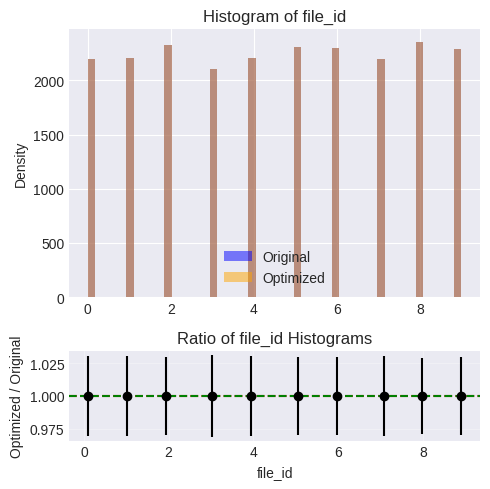

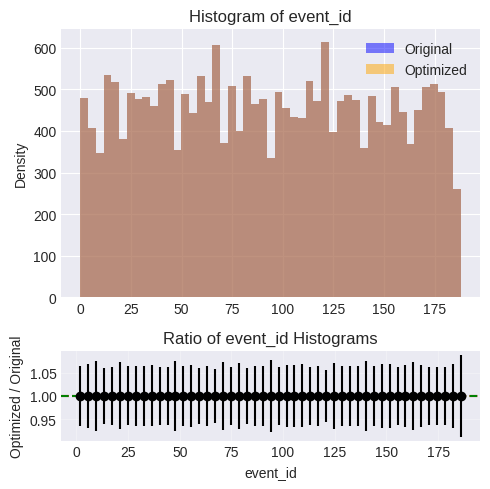

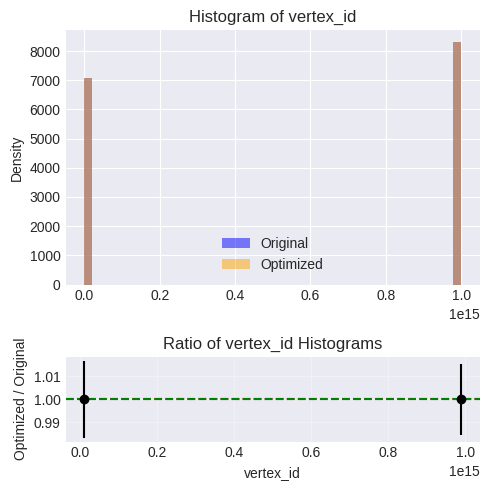

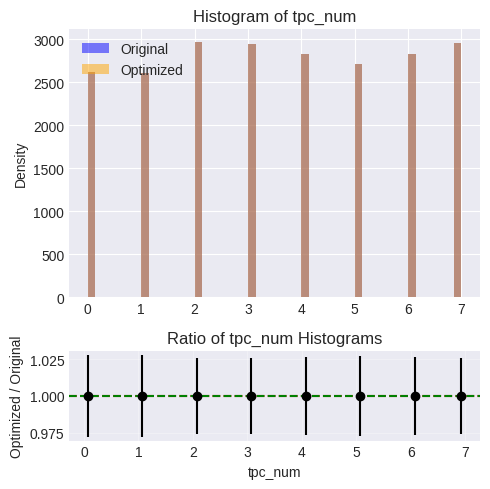

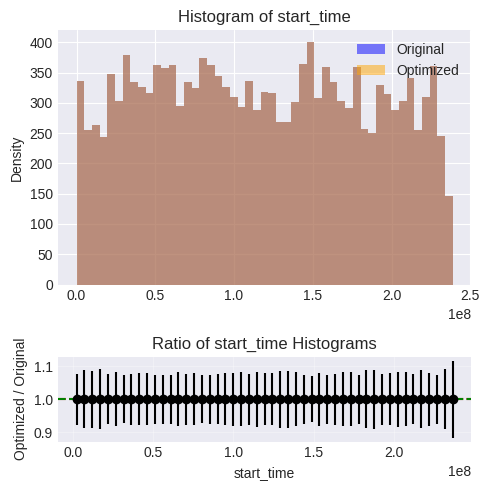

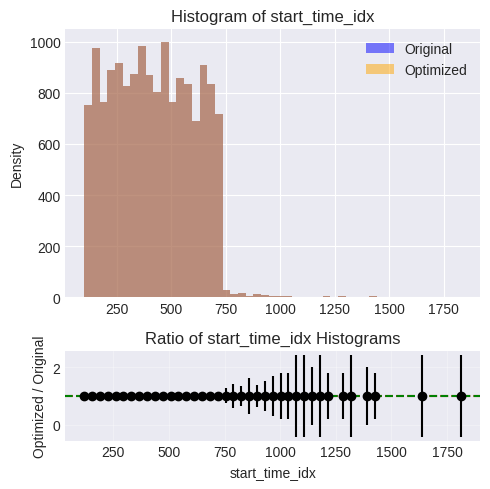

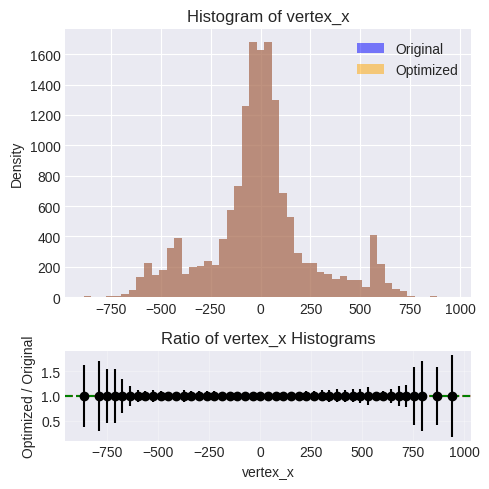

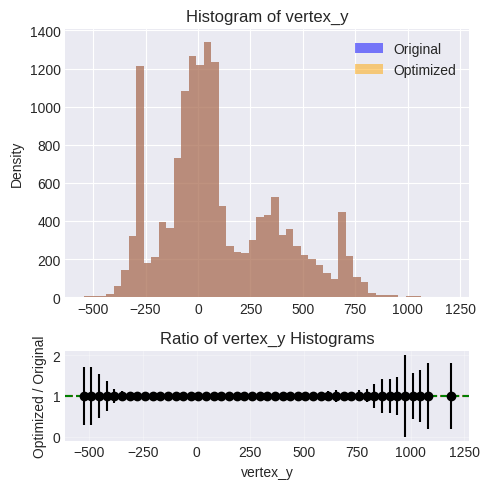

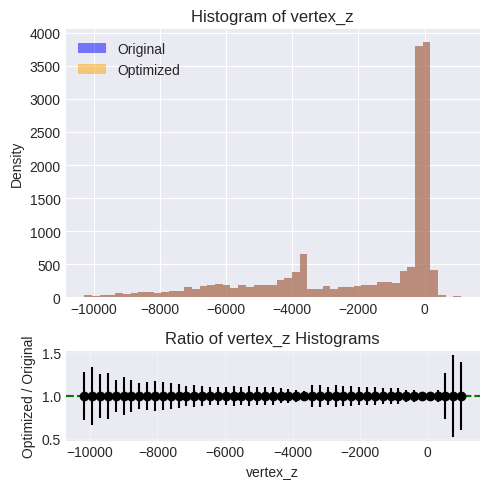

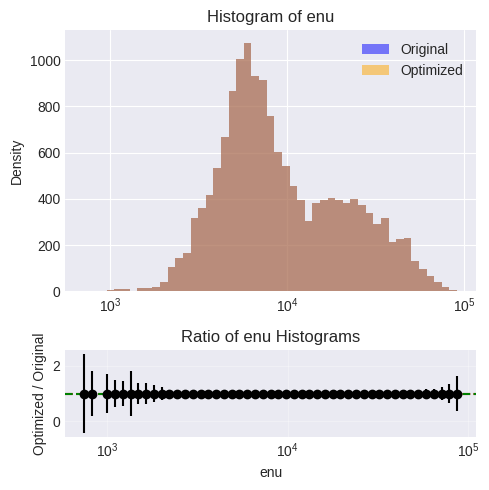

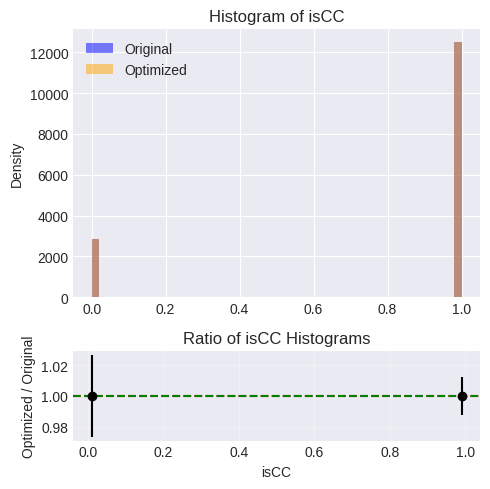

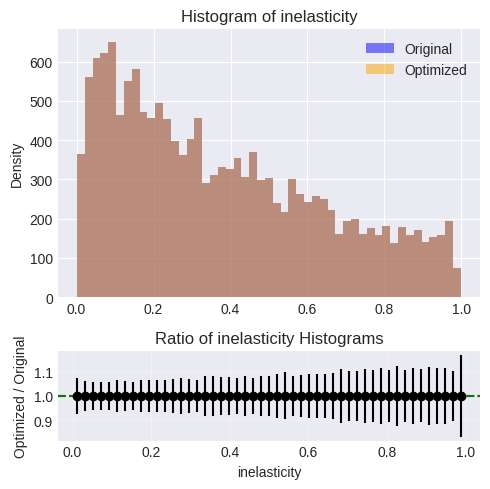

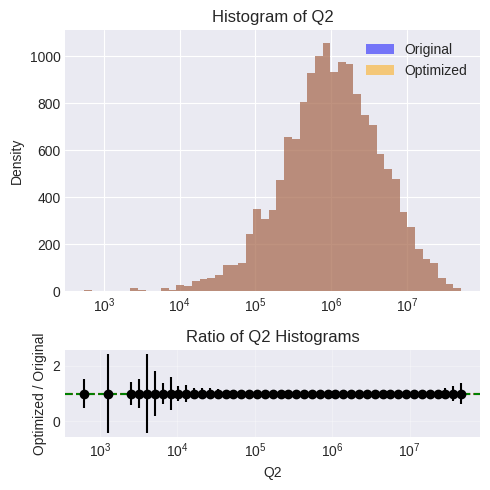

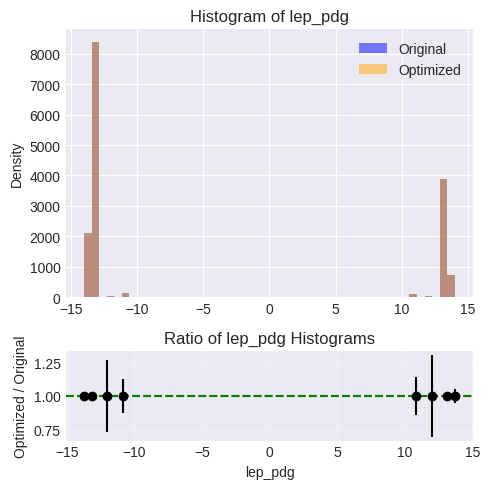

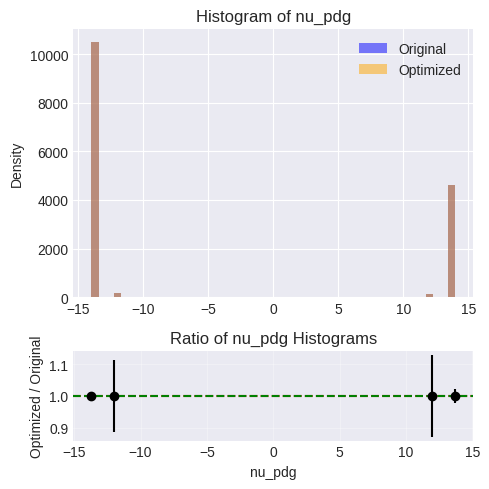

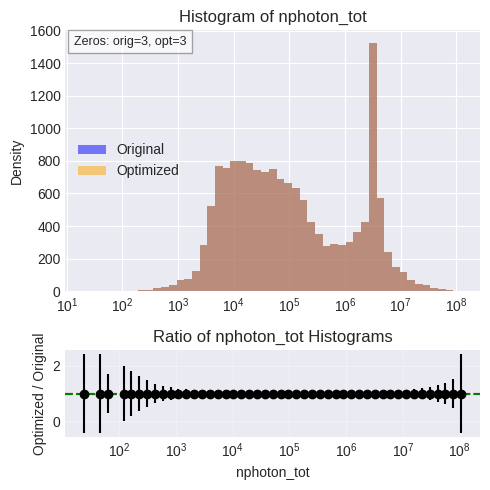

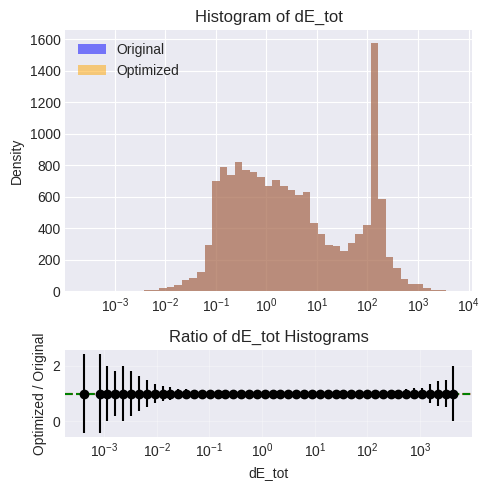

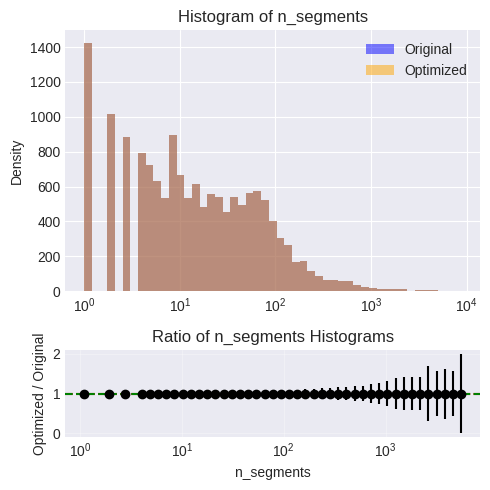

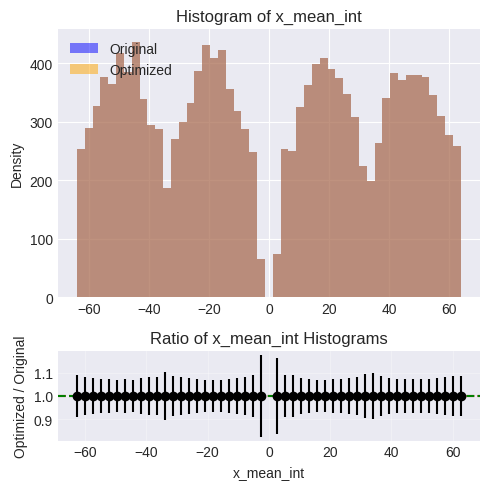

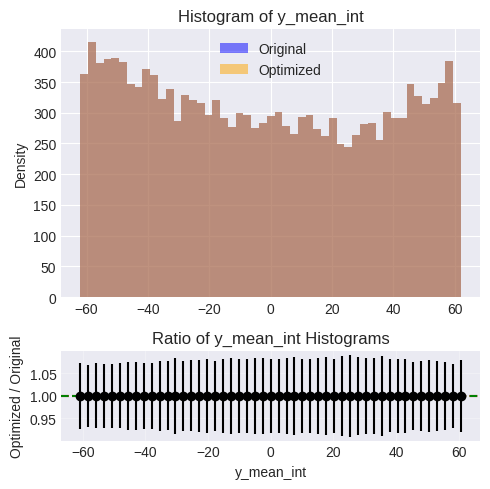

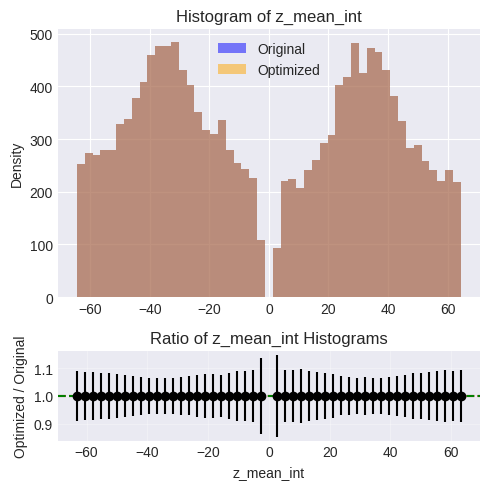

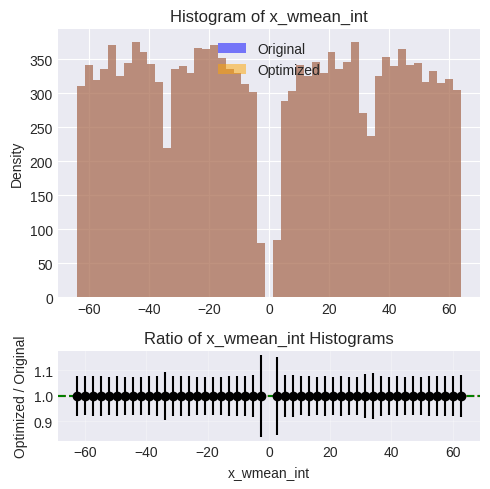

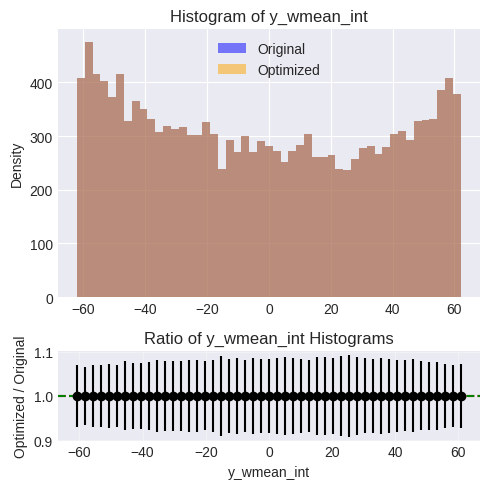

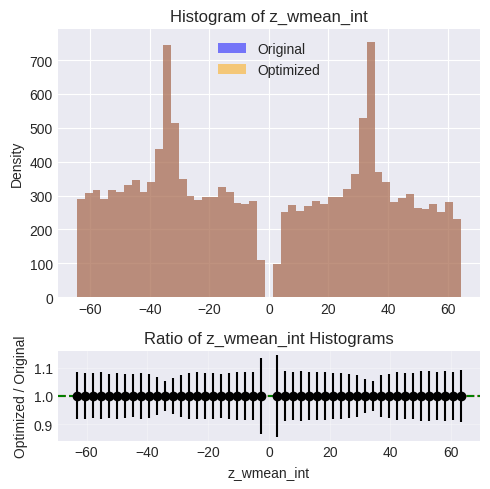

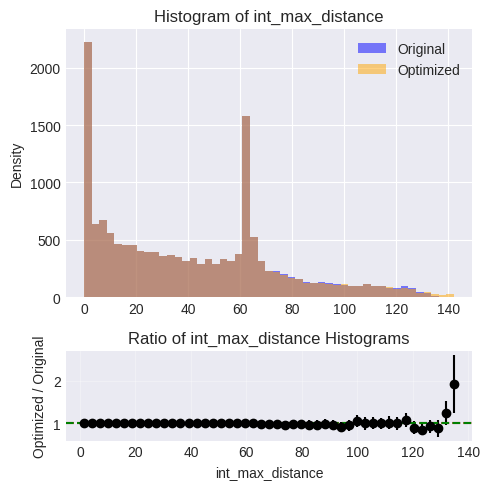

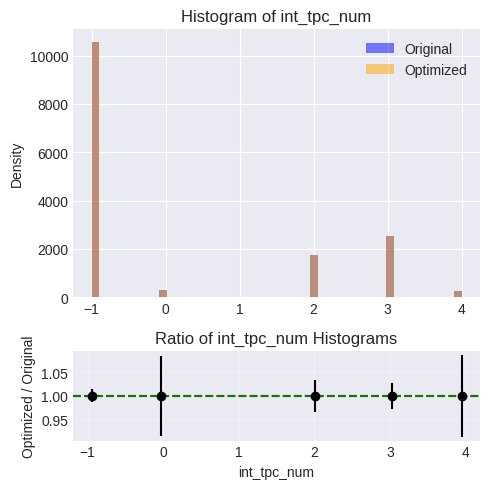

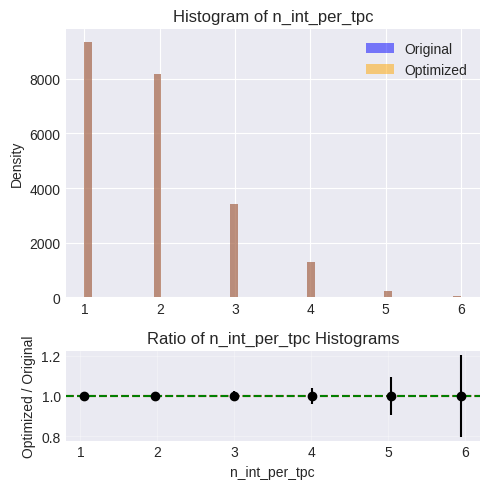

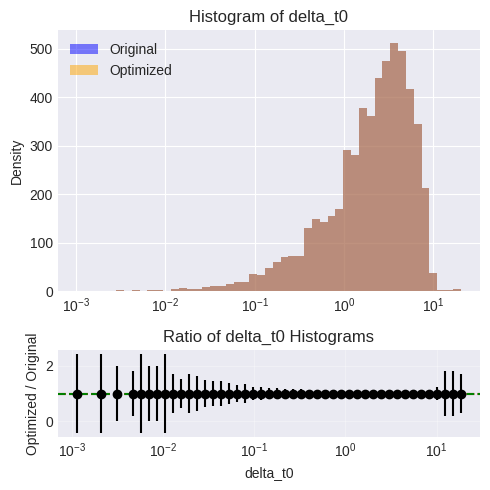

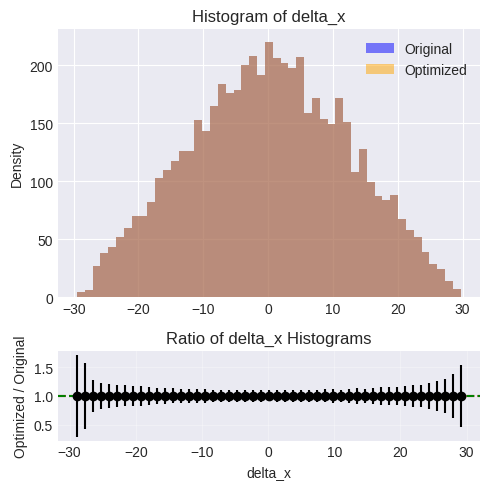

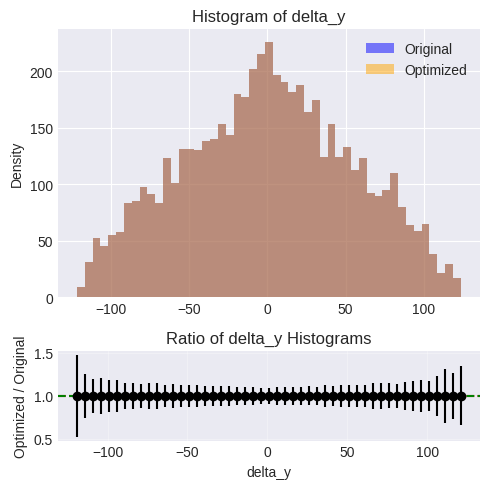

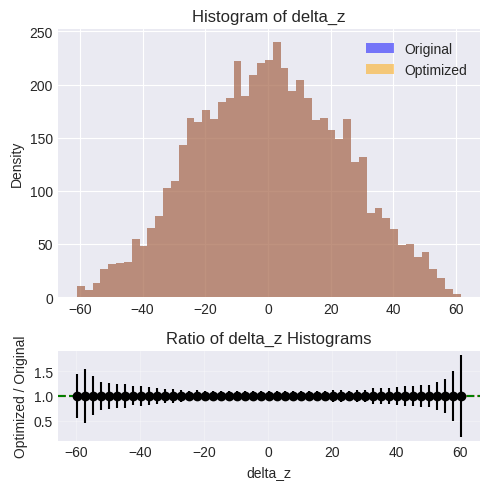

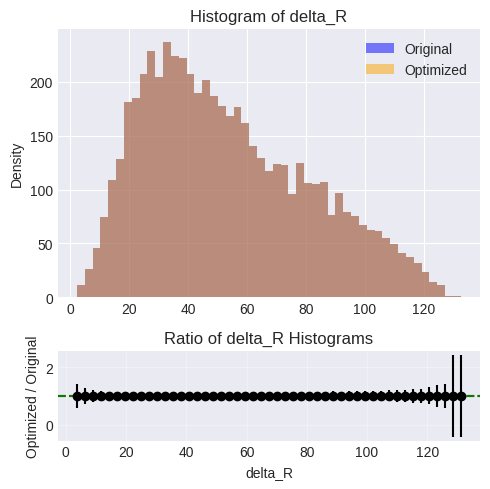

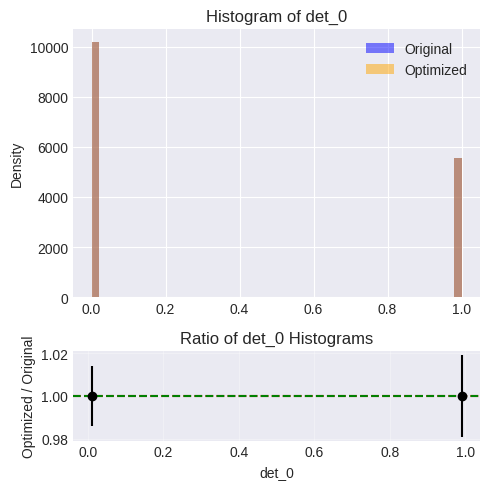

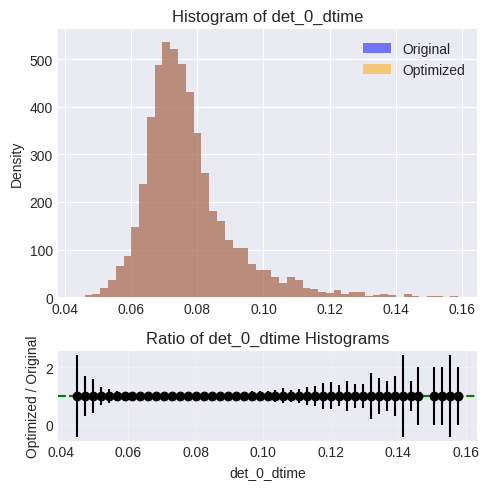

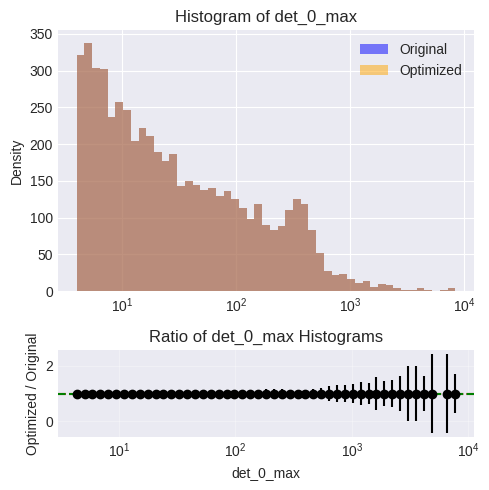

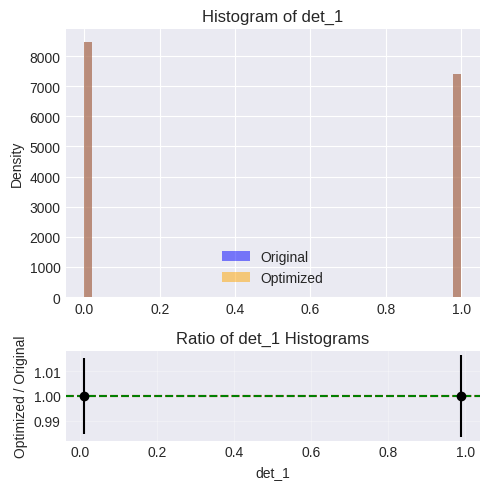

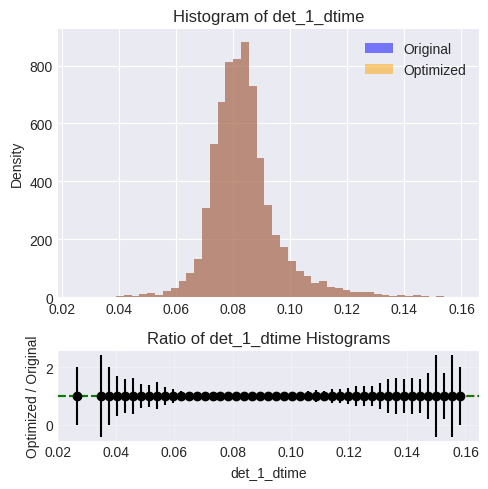

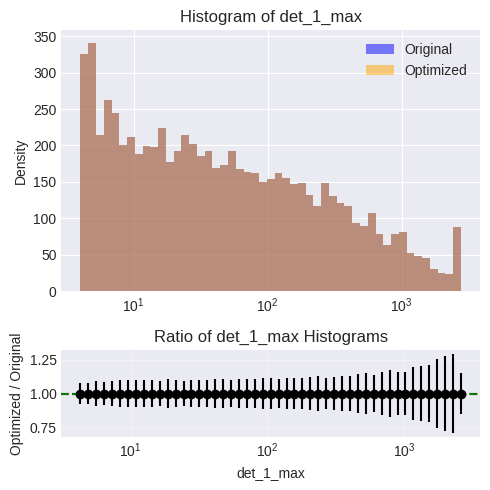

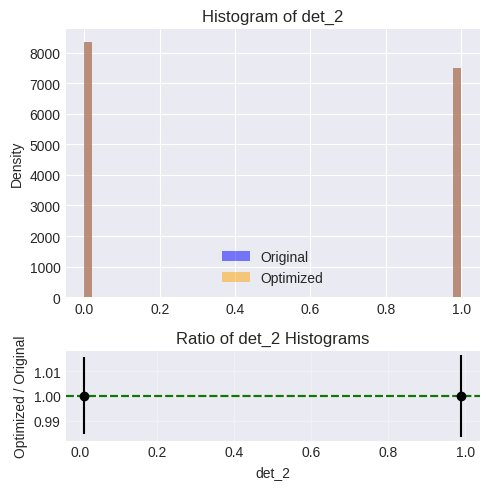

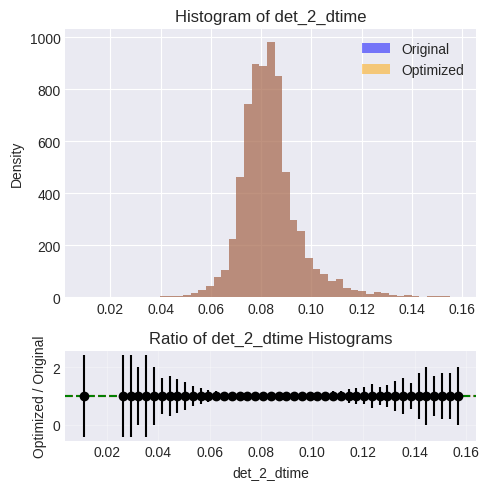

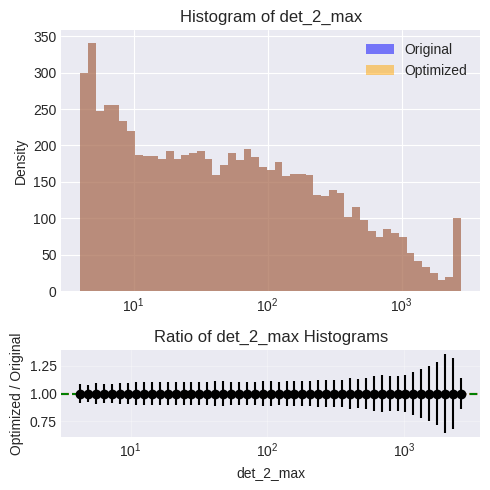

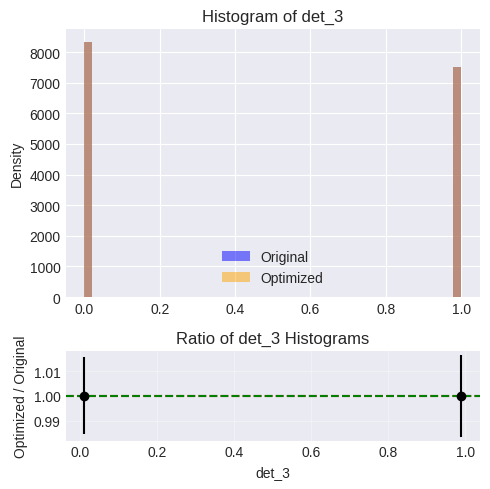

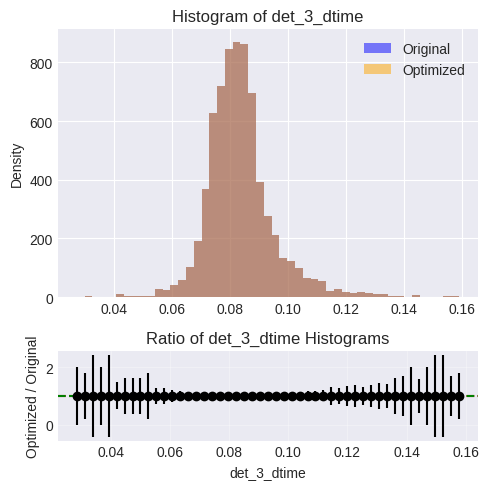

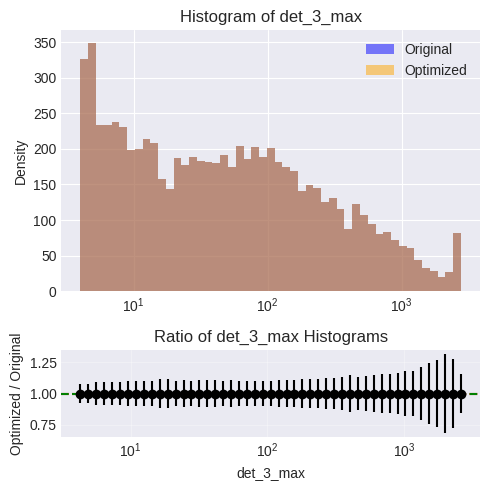

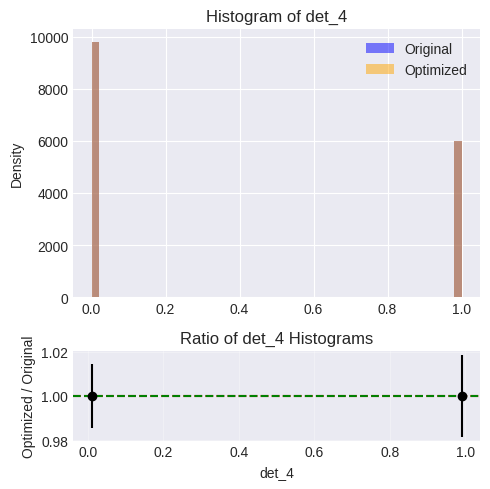

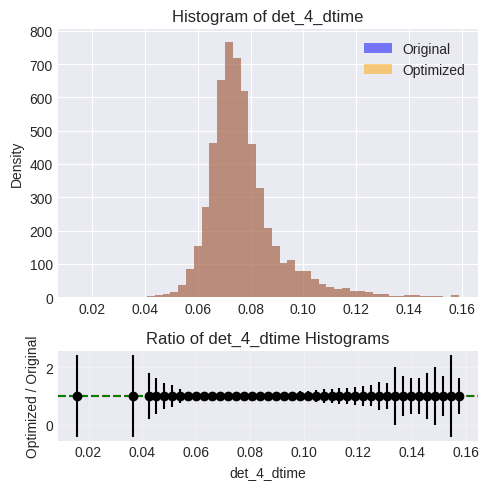

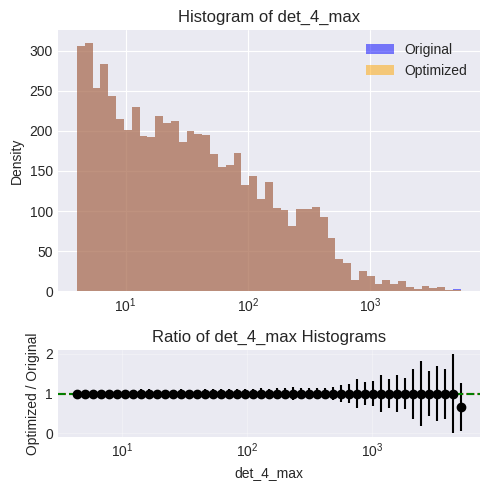

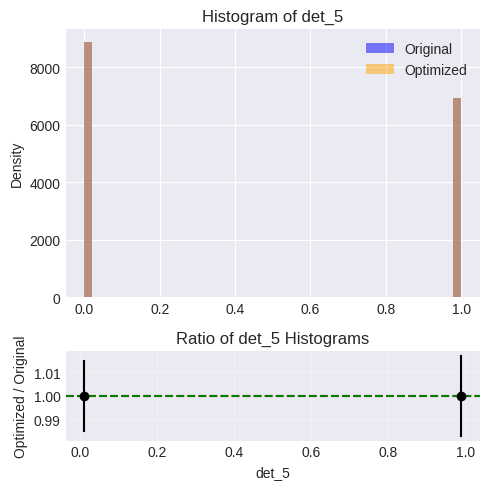

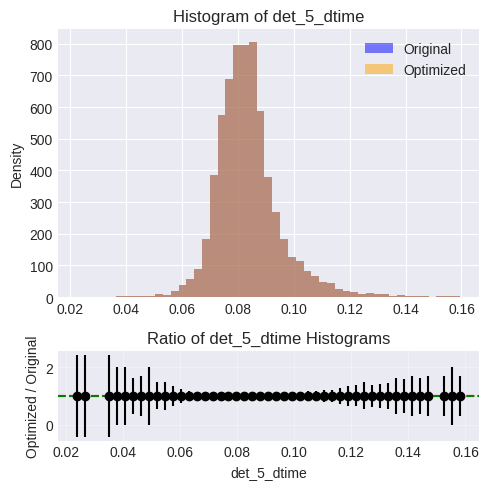

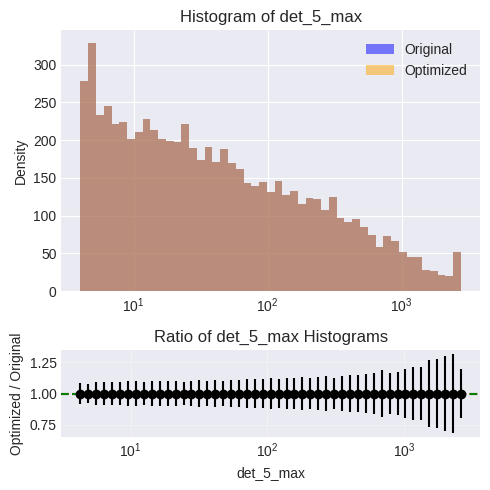

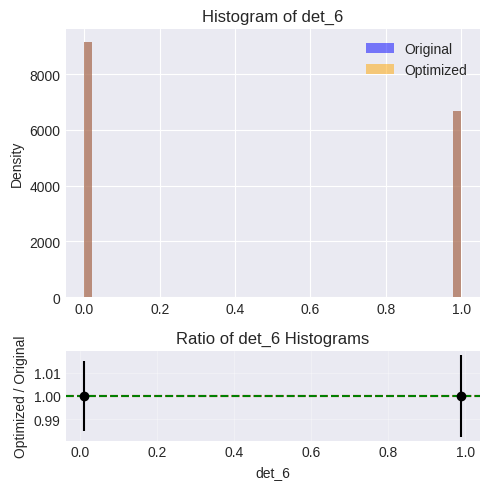

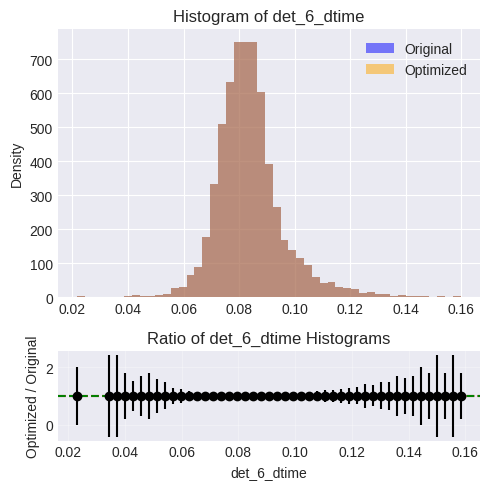

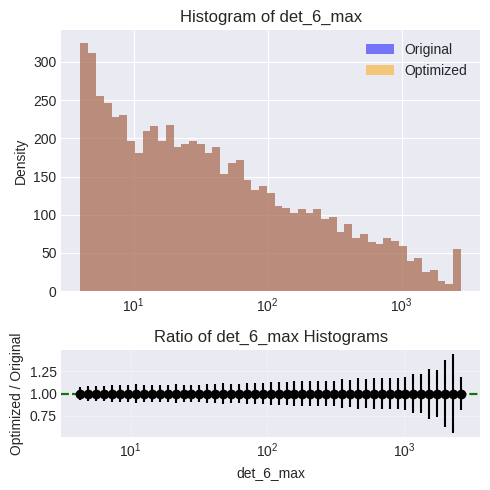

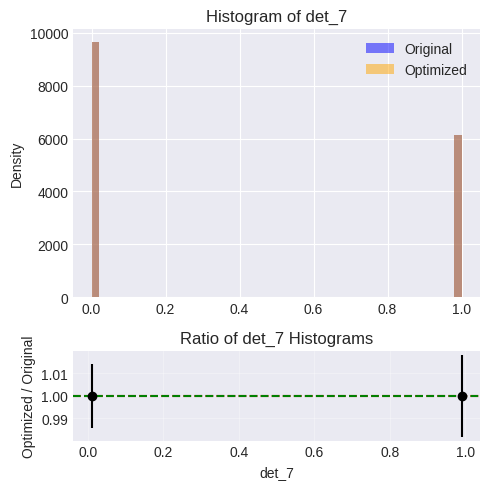

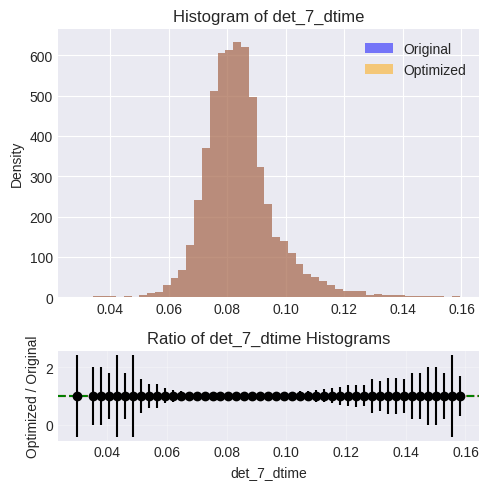

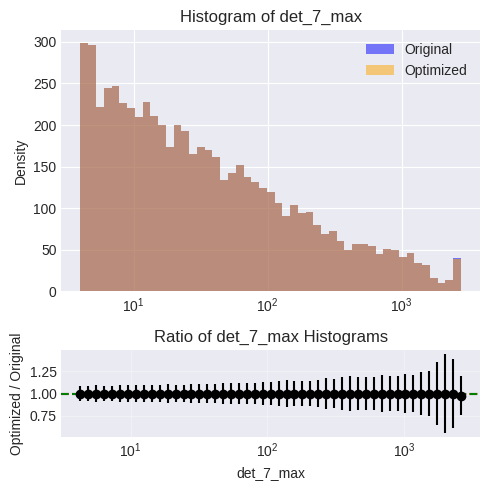

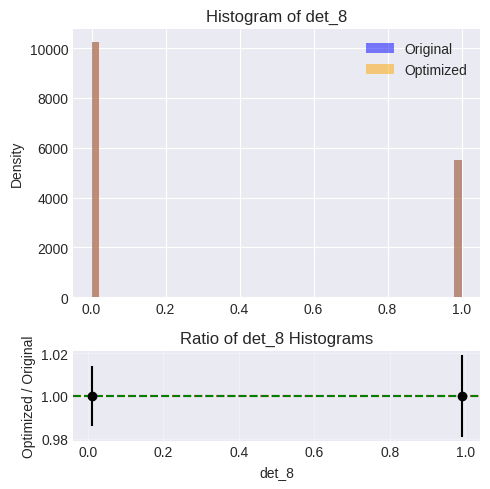

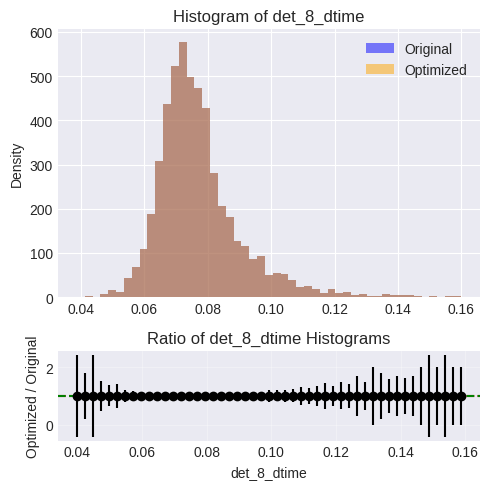

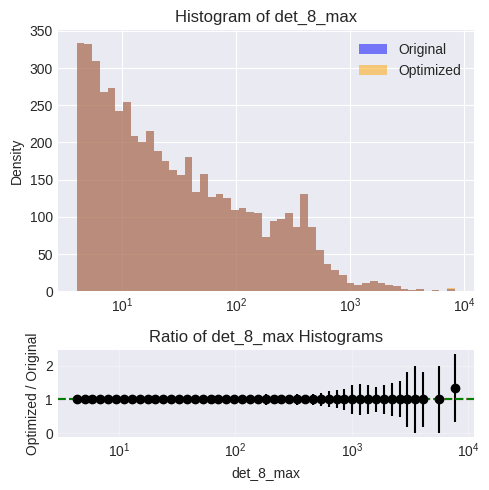

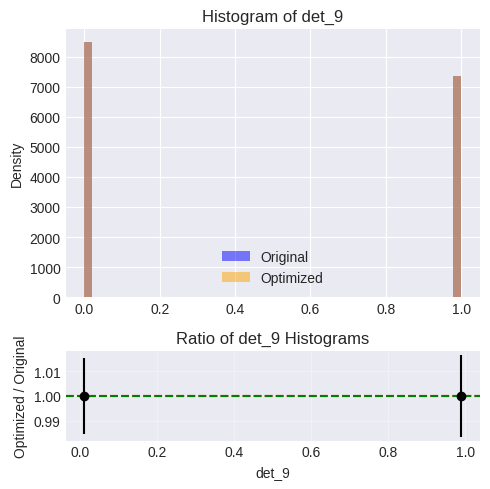

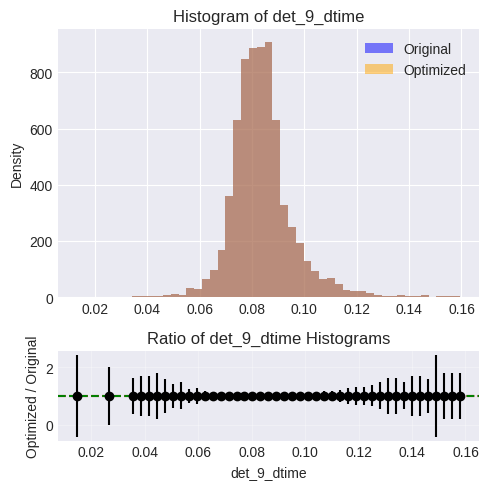

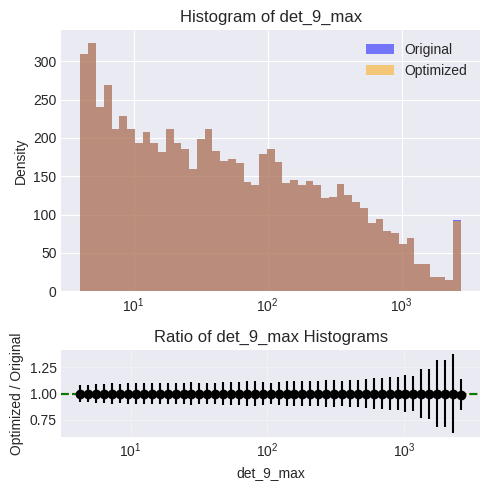

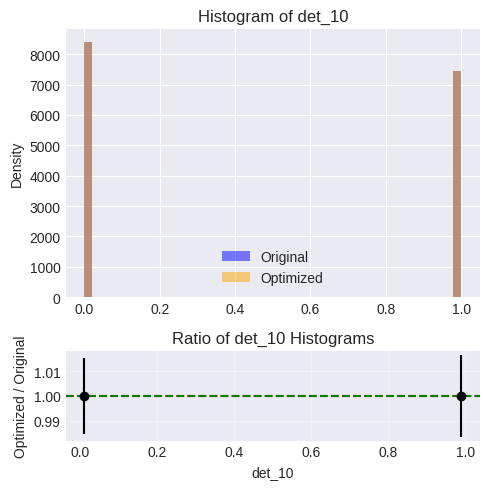

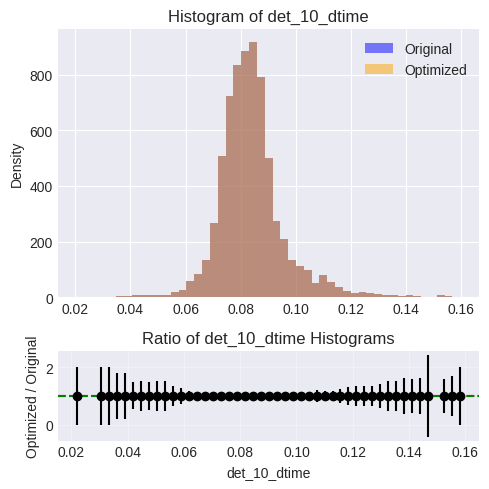

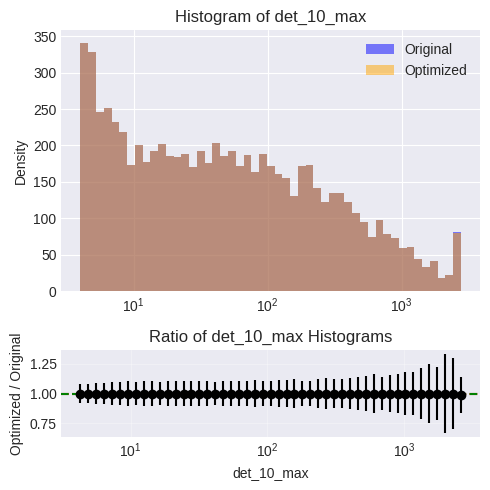

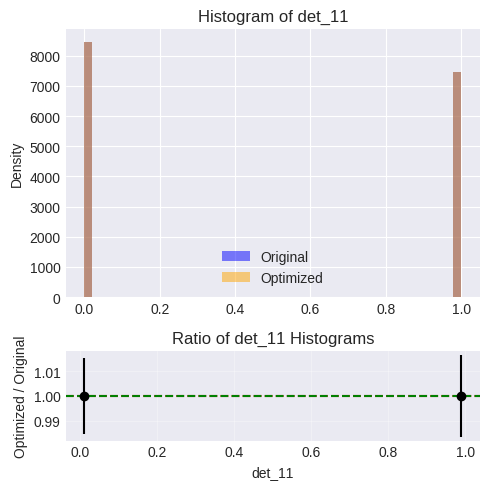

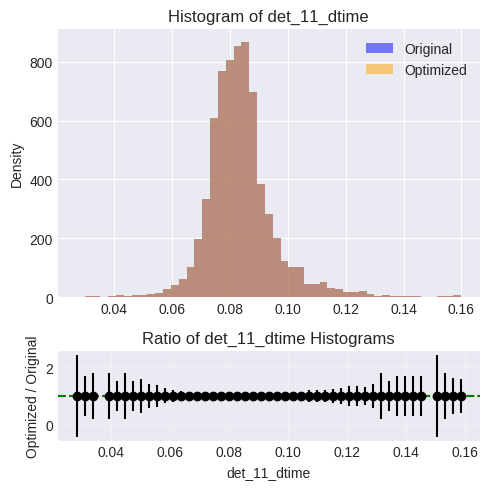

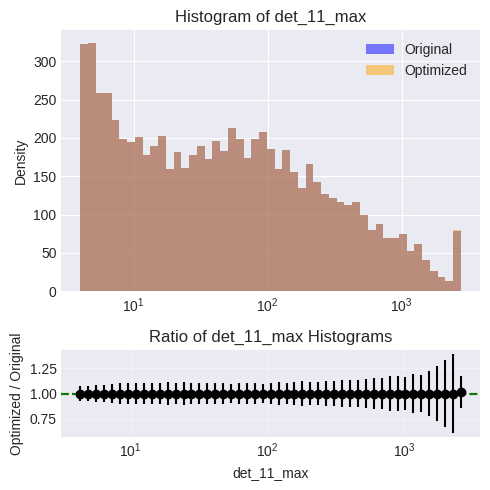

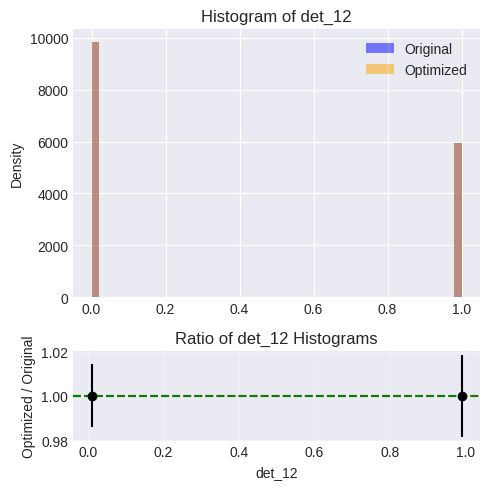

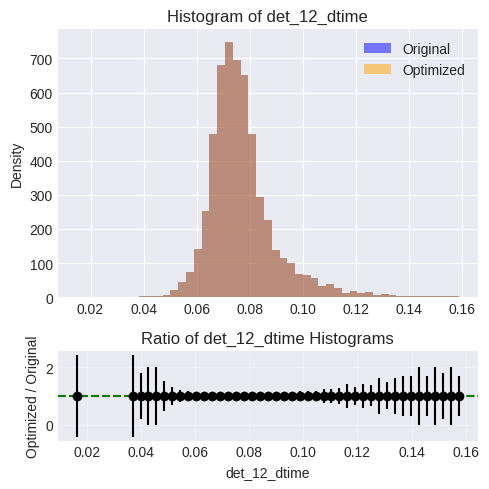

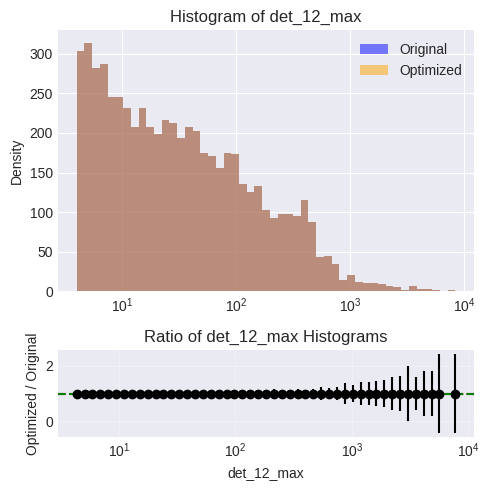

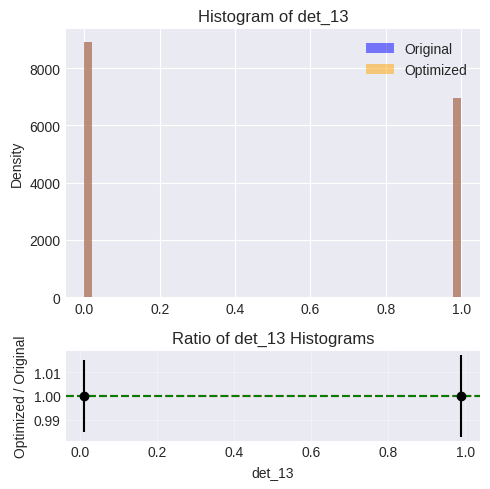

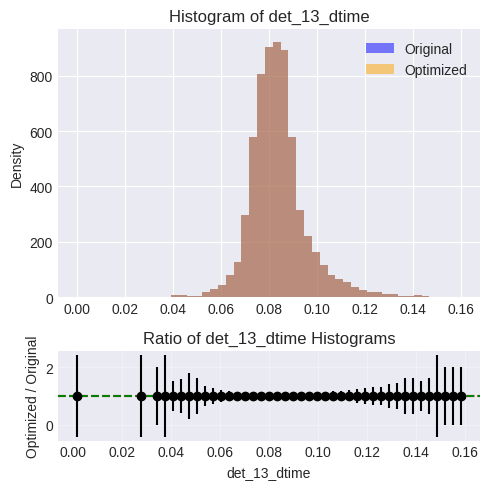

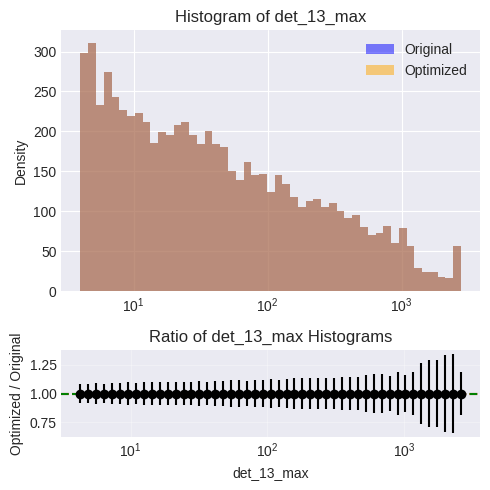

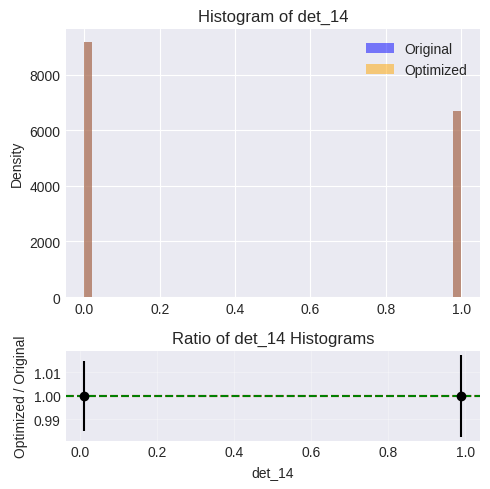

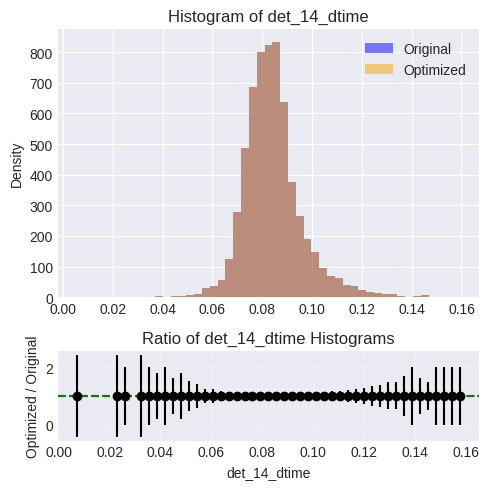

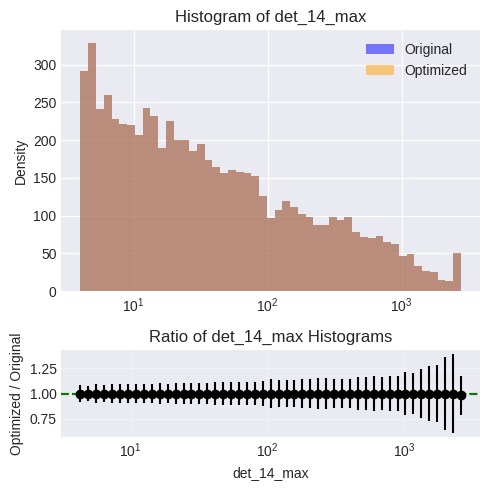

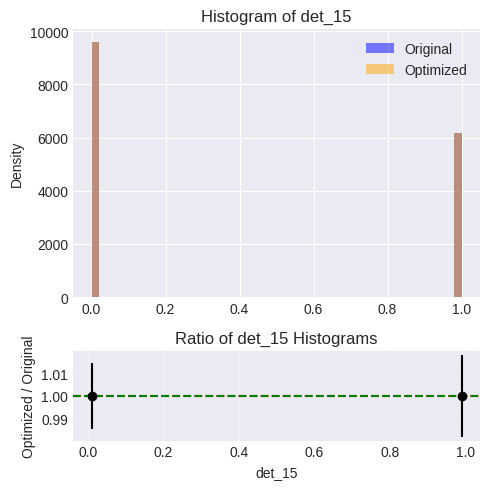

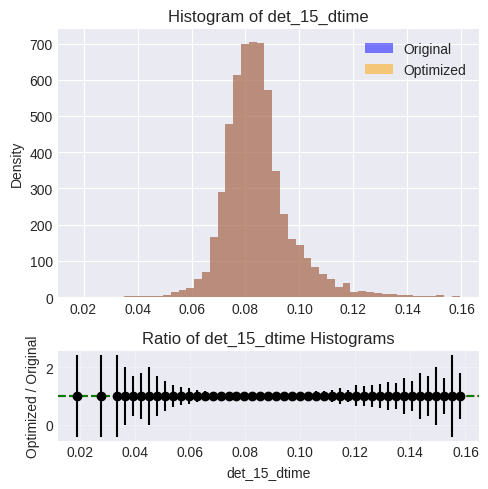

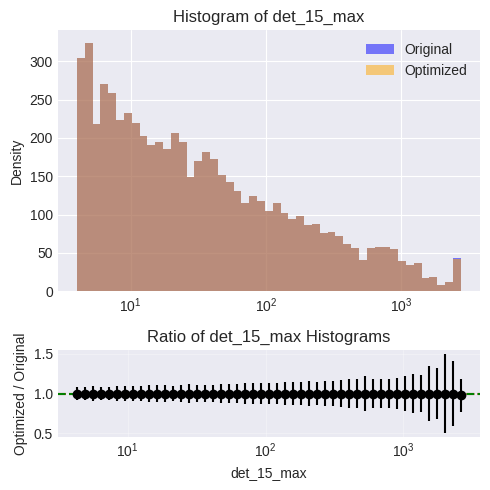

In [18]:

log_names = ['dE_tot', 'enu', 'Q2', 'nphoton_tot', 'n_segments', 'delta_t0', 'delta_Ifrac_nphotons']
# for det_#_max columns
for i in range(16):
    log_names.append(f'det_{i}_max')


for col in key_columns:
    if col in df_original.columns and col in df_optimized.columns:
        orig = df_original[col].dropna()
        opt = df_optimized[col].dropna()

        # Skip if empty
        if len(orig) == 0 or len(opt) == 0:
            print(f"Column '{col}' is empty in one of the dataframes. Skipping plot.")

        use_log = col in log_names

        if use_log:
            # Count zeros
            n_zero_orig = (orig == 0).sum()
            n_zero_opt = (opt == 0).sum()
            # Remove zeros for log binning
            orig_nonzero = orig[orig > 0]
            opt_nonzero = opt[opt > 0]
            if len(orig_nonzero) == 0 or len(opt_nonzero) == 0:
                print(f"Column '{col}' has only zeros or no positive values. Skipping log plot.")
                continue
            min_val = min(orig_nonzero.min(), opt_nonzero.min())
            max_val = max(orig_nonzero.max(), opt_nonzero.max())
            bins = np.logspace(np.log10(min_val), np.log10(max_val), 50)
        else:
            n_zero_orig = n_zero_opt = 0
            min_val = min(orig.min(), opt.min())
            max_val = max(orig.max(), opt.max())
            bins = np.linspace(min_val, max_val, 50)

        # Use nonzero data for log, all data for linear
        data_orig = orig_nonzero if use_log else orig
        data_opt = opt_nonzero if use_log else opt

        hist_orig, _ = np.histogram(data_orig, bins=bins)
        hist_opt, _ = np.histogram(data_opt, bins=bins)

        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = np.true_divide(hist_opt, hist_orig)
            ratio[~np.isfinite(ratio)] = np.nan
            err_ratio = np.full_like(ratio, np.nan, dtype=float)
            mask = (hist_orig > 0) & (hist_opt > 0)
            err_ratio[mask] = ratio[mask] * np.sqrt(1/hist_opt[mask] + 1/hist_orig[mask])

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 5), gridspec_kw={'height_ratios': [3, 1]})

        # Histograms
        ax1.hist(data_orig, bins=bins, alpha=0.5, label='Original', color='blue')#, density=True)
        ax1.hist(data_opt, bins=bins, alpha=0.5, label='Optimized', color='orange')#, density=True)
        ax1.set_ylabel('Density')
        ax1.set_title(f'Histogram of {col}')
        if use_log:
            ax1.set_xscale('log')
            # Annotate zeros if present
            if n_zero_orig > 0 or n_zero_opt > 0:
                ax1.text(0.02, 0.98, f'Zeros: orig={n_zero_orig}, opt={n_zero_opt}',
                         transform=ax1.transAxes, fontsize=9, va='top', ha='left',
                         bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))
        ax1.legend()

        # Ratio plot
        bin_centers = 0.5 * (bins[1:] + bins[:-1])
        ax2.errorbar(bin_centers, ratio, yerr=err_ratio, fmt='o', color='black')
        ax2.set_xlabel(col)
        ax2.set_ylabel('Optimized / Original')
        ax2.set_title(f'Ratio of {col} Histograms')
        ax2.axhline(1, color='red', linestyle='--')
        l_orig = len(data_orig)
        l_opt = len(data_opt)
        ratio_len = l_opt / l_orig if l_orig > 0 else np.nan
        ax2.axhline(ratio_len, color='green', linestyle='--', label='Length Ratio')
        ax2.grid(True, alpha=0.3)
        if use_log:
            ax2.set_xscale('log')
        #ax2.set_ylim(ratio_len - 0.2, ratio_len + 0.2)
        plt.tight_layout()
        plt.show()


In [19]:
'''
log_names = ['dE_tot', 'enu', 'Q2', 'nphoton_tot', 'n_segments', 'delta_t0', 'delta_Ifrac_nphotons']
# for det_#_max columns
for i in range(16):
    log_names.append(f'det_{i}_max')

for col in key_columns:
    if col in df_original.columns and col in df_optimized.columns:

        # get subset with only true interactions (not nan vertex_id and all det_# == 0)
        orig_true = df_original[(df_original['vertex_id'].notna()) & (df_original[[f'det_{i}' for i in range(16)]].sum(axis=1) == 0)]
        opt_true = df_optimized[(df_optimized['vertex_id'].notna()) & (df_optimized[[f'det_{i}' for i in range(16)]].sum(axis=1) == 0)]
        # get subset with only rec interactions (nan vertex_id and any det_# > 0)
        orig_rec = df_original[(df_original['vertex_id'].isna()) & (df_original[[f'det_{i}' for i in range(16)]].sum(axis=1) > 0)]
        opt_rec = df_optimized[(df_optimized['vertex_id'].isna()) & (df_optimized[[f'det_{i}' for i in range(16)]].sum(axis=1) > 0)]
        # get subset of true interactions with rec (det_# = 1) where # 0-15
        orig_true_rec = df_original[(df_original['vertex_id'].notna()) & (df_original[[f'det_{i}' for i in range(16)]].sum(axis=1) > 0)]
        opt_true_rec = df_optimized[(df_optimized['vertex_id'].notna()) & (df_optimized[[f'det_{i}' for i in range(16)]].sum(axis=1) > 0)]
        # Plot for three subsets: true, rec, true_rec
        subsets = [
            ('True', orig_true[col].dropna(), opt_true[col].dropna()),
            ('Rec', orig_rec[col].dropna(), opt_rec[col].dropna()),
            ('True+Rec', orig_true_rec[col].dropna(), opt_true_rec[col].dropna())
        ]

        fig, axes = plt.subplots(2, 3, figsize=(15, 7), gridspec_kw={'height_ratios': [3, 1]})
        for idx, (label, orig_sub, opt_sub) in enumerate(subsets):
            if len(orig_sub) == 0 or len(opt_sub) == 0:
                axes[0, idx].set_visible(False)
                axes[1, idx].set_visible(False)
                continue

            use_log = col in log_names
            if use_log:
                n_zero_orig = (orig_sub == 0).sum()
                n_zero_opt = (opt_sub == 0).sum()
                orig_nonzero = orig_sub[orig_sub > 0]
                opt_nonzero = opt_sub[opt_sub > 0]
                if len(orig_nonzero) == 0 or len(opt_nonzero) == 0:
                    axes[0, idx].set_visible(False)
                    axes[1, idx].set_visible(False)
                    continue
                min_val = min(orig_nonzero.min(), opt_nonzero.min())
                max_val = max(orig_nonzero.max(), opt_nonzero.max())
                bins = np.logspace(np.log10(min_val), np.log10(max_val), 50)
                data_orig = orig_nonzero
                data_opt = opt_nonzero
            else:
                n_zero_orig = n_zero_opt = 0
                min_val = min(orig_sub.min(), opt_sub.min())
                max_val = max(orig_sub.max(), opt_sub.max())
                bins = np.linspace(min_val, max_val, 50)
                data_orig = orig_sub
                data_opt = opt_sub

            hist_orig, _ = np.histogram(data_orig, bins=bins)
            hist_opt, _ = np.histogram(data_opt, bins=bins)

            with np.errstate(divide='ignore', invalid='ignore'):
                ratio = np.true_divide(hist_opt, hist_orig)
                ratio[~np.isfinite(ratio)] = np.nan
                err_ratio = np.full_like(ratio, np.nan, dtype=float)
                mask = (hist_orig > 0) & (hist_opt > 0)
                err_ratio[mask] = ratio[mask] * np.sqrt(1/hist_opt[mask] + 1/hist_orig[mask])

            ax1 = axes[0, idx]
            ax2 = axes[1, idx]

            # Histograms
            ax1.hist(data_orig, bins=bins, alpha=0.5, label='Original', color='blue')
            ax1.hist(data_opt, bins=bins, alpha=0.5, label='Optimized', color='orange')
            ax1.set_ylabel('Density')
            ax1.set_title(f'{label}: {col}')
            if use_log:
                ax1.set_xscale('log')
                if n_zero_orig > 0 or n_zero_opt > 0:
                    ax1.text(0.02, 0.98, f'Zeros: orig={n_zero_orig}, opt={n_zero_opt}',
                             transform=ax1.transAxes, fontsize=9, va='top', ha='left',
                             bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))
            ax1.legend()

            # Ratio plot
            bin_centers = 0.5 * (bins[1:] + bins[:-1])
            ax2.errorbar(bin_centers, ratio, yerr=err_ratio, fmt='o', color='black')
            ax2.set_xlabel(col)
            ax2.set_ylabel('Opt/Orig')
            ax2.set_title('Ratio')
            ax2.axhline(1, color='red', linestyle='--')
            l_orig = len(data_orig)
            l_opt = len(data_opt)
            ratio_len = l_opt / l_orig if l_orig > 0 else np.nan
            ax2.axhline(ratio_len, color='green', linestyle='--', label='Length Ratio')
            ax2.grid(True, alpha=0.3)
            if use_log:
                ax2.set_xscale('log')
            #ax2.set_ylim(ratio_len - 0.2, ratio_len + 0.2)

        plt.tight_layout()
        plt.show()
'''

"\nlog_names = ['dE_tot', 'enu', 'Q2', 'nphoton_tot', 'n_segments', 'delta_t0', 'delta_Ifrac_nphotons']\n# for det_#_max columns\nfor i in range(16):\n    log_names.append(f'det_{i}_max')\n\nfor col in key_columns:\n    if col in df_original.columns and col in df_optimized.columns:\n\n        # get subset with only true interactions (not nan vertex_id and all det_# == 0)\n        orig_true = df_original[(df_original['vertex_id'].notna()) & (df_original[[f'det_{i}' for i in range(16)]].sum(axis=1) == 0)]\n        opt_true = df_optimized[(df_optimized['vertex_id'].notna()) & (df_optimized[[f'det_{i}' for i in range(16)]].sum(axis=1) == 0)]\n        # get subset with only rec interactions (nan vertex_id and any det_# > 0)\n        orig_rec = df_original[(df_original['vertex_id'].isna()) & (df_original[[f'det_{i}' for i in range(16)]].sum(axis=1) > 0)]\n        opt_rec = df_optimized[(df_optimized['vertex_id'].isna()) & (df_optimized[[f'det_{i}' for i in range(16)]].sum(axis=1) > 0)]\n    